<div style="text-align:center; padding: 40px 0;">

<h1 style="font-size:2em; font-weight:bold; color:#1F4E79;">
Forecasting Philippine Coconut Oil Export Price Direction<br>
Using Supply Chain Friction Margins, ENSO Climate Signals,<br>
and Machine Learning Models
</h1>

<hr style="border: 2px solid #2E75B6; margin: 20px 60px;">

<p style="font-size:1.1em; color:#404040;">
<strong>LT 3</strong><br>
Asian Institute of Management · Philippines<br>
May 2026
</p>

<br>

<table style="margin:auto; border-collapse:collapse; font-size:0.95em;">
<tr><td style="padding:6px 20px; background:#D6E4F0; font-weight:bold;">Target Variable</td>
    <td style="padding:6px 20px;">Next-month CNO export price log-return direction (BUY / SELL)</td></tr>
<tr><td style="padding:6px 20px; background:#D6E4F0; font-weight:bold;">Model Dataset</td>
    <td style="padding:6px 20px;">June 2011 – November 2025 · 131 monthly observations after lag construction</td></tr>
<tr><td style="padding:6px 20px; background:#D6E4F0; font-weight:bold;">Models Evaluated</td>
    <td style="padding:6px 20px;">9 model families evaluated with and without explicit SCFM features</td></tr>
<tr><td style="padding:6px 20px; background:#D6E4F0; font-weight:bold;">Evaluation Method</td>
    <td style="padding:6px 20px;">48-month rolling-window backtest · 83 out-of-sample predictions</td></tr>
<tr><td style="padding:6px 20px; background:#D6E4F0; font-weight:bold;">Best Result</td>
    <td style="padding:6px 20px;">GBM Regressor without explicit SCFM · 72.29% directional accuracy · +17.33pp vs 54.96% majority baseline</td></tr>
</table>

</div>


---

## 1. Executive Summary

This project evaluates whether Coconut oil (CNO) export price direction can be forecast using domestic supply-chain variables, international vegetable-oil market signals, exchange-rate movements, production data, and ENSO climate indicators. The target is the next-month CNO export price log-return direction, framed as a BUY/SELL classification problem based on whether the following month’s log return is positive or negative.

The notebook builds a final monthly modeling dataset of 131 observations from June 2011 to November 2025 after lag construction. The project evaluates nine model families under a 48-month rolling-window backtest, producing 83 out-of-sample predictions. The strongest stored result is the Gradient Boosting Regressor without explicit SCFM features, which achieves 72.29% directional accuracy, compared with a 54.96% majority-class baseline, an improvement of +17.33 percentage points. The main recommendation is to use the model as a decision-support signal for near-term price direction monitoring, not as a standalone trading, procurement, or price-level forecasting system.

---

## 2. Introduction

Coconut oil is a strategically relevant Philippine agricultural export because the Philippines is identified as one of the major coconut-producing and coconut-oil-producing countries. Global Info Research (2024) notes that coconut trees are widely distributed in the Philippines, Indonesia, India, Sri Lanka, and Malaysia, and that the Philippines, Indonesia, and India account for more than 70% of global coconut production; as a result, coconut oil production is also concentrated in these countries. The same market description identifies Philippine firms such as Tantuco Enterprises, Greenville Agro Corporation, Samar Coco Products, CIIF OMG, Primex Group, SC Global, and Phidco among coconut oil market participants (Global Info Research, 2024).

CNO export prices matter because coconut oil is traded in a global market shaped by regional production, industrial demand, food-sector demand, and competition among major suppliers. Global Info Research describes coconut oil as an edible oil extracted from mature coconut kernel or meat and segments the market by input type, including fresh coconut and dry copra, and by application, including industrial use and the food industry (Global Info Research, 2024). Price direction can therefore affect exporters, processors, traders, policymakers, and indirectly smallholder coconut producers through procurement timing, inventory policy, contract negotiation, hedging decisions, and market monitoring.

The project addresses a forecasting problem: whether next-month Philippine CNO export price direction can be predicted using lagged market, supply-chain, exchange-rate, production, and climate information. This framing is consistent with a market context in which coconut oil prices are affected not only by global edible-oil conditions but also by domestic supply-chain factors linked to coconut and copra availability. To capture this domestic cost channel, the project constructs a Supply Chain Friction Margin, or SCFM, defined as the gap between the CNO export price and copra input cost adjusted by an assumed oil extraction rate.

The scope is monthly directional forecasting, not exact price-level prediction. This distinction is critical. The model predicts whether the next-month CNO log return is positive or negative; it does not establish that the model accurately forecasts the next CNO price level. The notebook itself correctly identifies this limitation and warns that the trading simulation should not be interpreted as evidence of a deployable trading strategy.

## 3. Business Value 

The project has business value because it converts fragmented commodity, exchange-rate, production, and climate data into a structured monthly signal about likely CNO export price direction. For exporters and processors, such a signal can support procurement timing, inventory planning, and contract discussion. For policymakers and agricultural analysts, it can provide an early-warning indicator of changing price conditions in a commodity linked to rural livelihoods and export earnings.

The most defensible value is improved decision support, not automated decision-making. The best model’s 72.29% out-of-sample directional accuracy exceeds the 54.96% majority-class baseline, suggesting that the feature set contains predictive information. However, the dataset is small, the backtest contains only 83 out-of-sample months, and the notebook does not provide a fully executed and validated operational trading or procurement simulation. Therefore, the model should be treated as a monitoring tool that can improve situational awareness rather than as a complete commercial forecasting product.

---

## 2. Data [BIG NOTE BELLOW IS A DRAFT PA LANG]

### 2.1 Data Sources

All prices are expressed in **USD per metric tonne (USD/MT)**. Listed below are our base variables and metadata.

| Variable | Source | Frequency | Collection Method | Unit |
|---|---|---|---|---|
| CNO export price | World Bank Pink Sheet | Monthly | Direct download | USD/MT |
| Copra Corriente farmgate price | PSA OpenSTAT API | Monthly | API | PHP/kg → USD/MT |
| Malaysian CPO futures | Investing.com | Weekly → monthly lags | Download | USD/MT |
| USD/PHP exchange rate | Investing.com | Weekly → monthly lags | Download | PHP per USD |
| Oceanic Niño Index (ONI) | NOAA CPC | Monthly | Web scrape | Dimensionless |
| Coconut Mature production | PSA OpenSTAT API | Quarterly | API | Metric tons |


The final feature set was designed to predict the next-month direction of Philippine coconut oil export-price log returns using lagged international market, exchange-rate, domestic production, climate, and supply-chain variables. It contains 22 columns in total, consisting of the monthly date identifier, the current coconut oil export price, 19 predictor features, and the target variable.

The target variable is `target_next_cno_log_return`, which represents the next-month log return of coconut oil export prices. Using returns rather than raw price levels is appropriate because financial and commodity-price analysis commonly models proportional price change instead of absolute price levels, making movements more comparable across time and price scales (Brooks, 2014). The use of lagged variables is critical because forecasting models must only use information available before the prediction period; otherwise, the model may suffer from look-ahead bias (Brownlee, 2020). Brownlee (2020) emphasizes that time series data is restructured into a supervised learning problem "by using the value at the previous time step to predict the value at the next time-step," and he explicitly warns against invalid framing where "the input would contain knowledge of the future being predicted.".



### 2.2 Target Variable

The target variable is the **one-month forward log return** of CNO export prices:

$$y_t = \ln\left(\frac{P_{t+1}^{\text{CNO}}}{P_t^{\text{CNO}}}\right)$$

For classification models, a binary direction target is derived: $\tilde{y}_t = \mathbf{1}[y_t > 0]$, where 1 = price increase (BUY) and 0 = price decrease (SELL).

### 2.3 Unit Conversions

Copra farmgate prices are reported by PSA in **PHP/kg**. Conversion to USD/MT for SCFM computation:

$$P_t^{\text{copra,USD/MT}} = \frac{P_t^{\text{copra,PHP/kg}} \times 1000}{e_t}$$

where $e_t$ is the monthly-mean USD/PHP exchange rate. Using the monthly mean rather than the end-of-month rate introduces minor FX basis noise, as copra transactions may occur at a distribution of intra-month rates. This is acknowledged as a minor measurement limitation.

### 2.4 ENSO Signal

The Oceanic Niño Index (ONI) measures sea surface temperature anomalies in the Niño 3.4 region (central equatorial Pacific):
- ONI ≥ +0.5°C → **El Niño** (drought risk in Philippines → lower coconut yields)
- ONI ≤ −0.5°C → **La Niña** (flooding risk in Philippines)
- −0.5 < ONI < +0.5 → **Neutral**

ONI is lagged by 1 to 4 months in the feature set, with the model learning the delayed crop impact from data.

---

## 3. Methodology

### 3.1 Supply Chain Friction Margin (SCFM)

The SCFM is the central novel feature of this study, defined as:

$$\text{SCFM}_t = P_{t-1}^{\text{CNO}} - \frac{P_{t-1}^{\text{copra,USD/MT}}}{\kappa}$$

where κ = 0.63 is the oil extraction rate (kg CNO per kg copra), sourced from Kumar Metal Industries (2025) who document approximately 610 kg CNO yield per metric tonne of copra. The SCFM is expressed on a **per-metric-tonne-of-CNO-produced basis** — that is, it represents the crush margin per unit of oil output rather than per unit of copra input. All SCFM features are computed from **lagged values only** to prevent contemporaneous leakage.

### 3.2 Weekly Lagged Features

Weekly CPO futures and USD/PHP exchange rate observations are aggregated to monthly frequency using a lagged rolling mean. For each monthly observation, the model receives N_LAGS = 4 lagged monthly values of each weekly series. This preserves the temporal structure of world palm oil price movements and exchange rate dynamics across recent months, allowing the model to learn delayed transmission effects on CNO prices.

This approach is functionally equivalent to the supervised lagged-feature formulation of Unrestricted MIDAS (Foroni, Marcellino, and Schumacher, 2015), in which each lag enters the model as an independent feature with a freely estimated coefficient. No polynomial weight constraint is applied to the lags.

### 3.3 Rolling-Window Backtest

To avoid lookahead bias and simulate realistic forecasting conditions, we use a **sliding-window backtest**:
- Training window: 48 months (fixed)
- Test window: 1 month
- Step: 1 month
- Total out-of-sample predictions: 83

At each step, models are trained exclusively on the preceding 48 months. StandardScaler is refit on each training window. Class weights for classifiers are recomputed from each training window's class distribution. The naive persistence baseline is computed from the full lagged target series before the out-of-sample slice is taken, so the first out-of-sample month uses the final in-sample observation as its lagged prediction. This keeps the baseline evaluation window aligned with the 83 model predictions.

### 3.4 Feature Importance

Feature importances are computed as **fold-averaged gain** across all rolling training windows to avoid contamination from the full-sample model. At each fold, the trained XGBoost model's feature importances are stored. The final reported importance for each feature is the mean across all folds.

### 3.5 Statistical Significance

A **block bootstrap** (10,000 iterations, block size = 6 months) tests the null hypothesis that model directional accuracy does not exceed the majority-class baseline. Block size 6 preserves the autocorrelation structure of monthly commodity returns. Robustness is confirmed by testing block sizes 3, 6, 9, and 12.

### 3.6 SCFM Comparison Framework

Two feature specifications are evaluated for each model:
- **With SCFM:** includes `scfm`, `scfm_lag1`, `scfm_mean6`, `scfm_dev`
- **Without SCFM:** excludes all SCFM-derived columns

The SCFM impact per model is reported as:

$$\text{SCFM impact} = \text{DA}_{\text{with SCFM}} - \text{DA}_{\text{without SCFM}}$$

A positive value indicates the explicit SCFM feature improved directional accuracy. A negative value indicates the model performed better without it.

### 3.7 Models

| Model | Scaling | Key Hyperparameters |
|---|---|---|
| Linear Regression | Yes | — |
| Ridge Regression | Yes | α = 1.0 |
| KNN Regressor | Yes | k = 5, distance weights |
| SVM Regressor | Yes | RBF, C = 1.0 |
| Decision Tree Regressor | No | max_depth = 3 |
| Random Forest Regressor | No | 100 trees, max_depth = 3 |
| GBM Regressor | No | 100 trees, max_depth = 2 |
| XGBoost Regressor | No | max_depth = 2, λ = 5.0 |


---

## 4. Implementation


### 4.1 Imports and Settings


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

# ── Global settings ───────────────────────────────────────────
START_DATE = "2010-05-01"
KAPPA      = 0.63       # oil extraction rate: kg CNO per kg copra
                        # ~610 kg CNO per MT copra (Kumar Metal Industries, 2025)
N_LAGS     = 4          # monthly lag depth
TRAIN_SIZE = 48         # rolling window training months
SEED       = 42

print(f"Settings: START={START_DATE} | KAPPA={KAPPA} | N_LAGS={N_LAGS} | TRAIN={TRAIN_SIZE}mo")



Settings: START=2010-05-01 | KAPPA=0.63 | N_LAGS=4 | TRAIN=48mo


### 4.2 Load Datasets


In [2]:
cno_export_prices_raw = pd.read_csv("datasets/cno_export_prices.csv")
coco_prod_raw         = pd.read_csv("datasets/coconut_production.csv")
copra_farmgate_raw    = pd.read_csv("datasets/copra_farmgate.csv")
cpo_futures_raw       = pd.read_csv("datasets/cpo_futures.csv")
oni_monthly_raw       = pd.read_csv("datasets/oni_monthly.csv")
usd_php_raw           = pd.read_csv("datasets/usd_php.csv")
print("All raw datasets loaded.")



All raw datasets loaded.


### 4.3 Cleaning Functions


In [3]:
def clean_price_df(raw_df, value_name, date_col="Date", price_col="Price",
                   start_date=START_DATE):
    df = raw_df.copy()
    df.columns = df.columns.astype(str).str.strip()
    df = df[[date_col, price_col]].rename(columns={date_col: "date", price_col: value_name})
    df["date"]     = pd.to_datetime(df["date"], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return (df.dropna(subset=["date", value_name])
              .query("date >= @start_date")
              .sort_values("date")
              .reset_index(drop=True))

def month_start(df, date_col="date"):
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out[date_col] = out[date_col].dt.to_period("M").dt.to_timestamp()
    return out



### 4.4 Clean Each Dataset


In [4]:
# CNO export prices (USD/MT)
cno_export_prices = clean_price_df(cno_export_prices_raw, "cno_price",
                                   date_col="Date", price_col="Price")
cno_export_prices = (month_start(cno_export_prices)
                     .groupby("date", as_index=False)["cno_price"].mean()
                     .sort_values("date").reset_index(drop=True))

# Coconut production (MT) — quarterly → monthly via forward-fill
coco_prod_clean = coco_prod_raw[["Year","Quarter","Volume"]].dropna(subset=["Quarter","Volume"]).copy()
coco_prod_clean["Year"] = coco_prod_clean["Year"].ffill().astype(int)
q2m = {"Quarter1":1,"Quarter2":4,"Quarter3":7,"Quarter4":10}
coco_prod_clean["month"] = coco_prod_clean["Quarter"].map(q2m)
coco_prod_clean["date"]  = pd.to_datetime(
    coco_prod_clean["Year"].astype(str)+"-"+coco_prod_clean["month"].astype(str).str.zfill(2)+"-01",
    errors="coerce")
coco_prod_clean["coconut_prod"] = pd.to_numeric(coco_prod_clean["Volume"], errors="coerce")
prod_quarterly = coco_prod_clean[["date","coconut_prod"]].dropna().sort_values("date").reset_index(drop=True)
prod_monthly   = (prod_quarterly.set_index("date").sort_index()
                  .resample("MS").ffill().reset_index())
prod_monthly   = prod_monthly[prod_monthly["date"]>=START_DATE].reset_index(drop=True)

# Copra Corriente farmgate (PHP/kg) — wide → long
copra_farmgate = copra_farmgate_raw.copy()
copra_farmgate.columns = copra_farmgate.columns.astype(str).str.strip()
copra_farmgate = copra_farmgate.melt(var_name="date_raw", value_name="copra_farmgate")
copra_farmgate["date"] = pd.to_datetime(
    copra_farmgate["date_raw"].astype(str).str.replace(" Copra Corriente","",regex=False).str.strip(),
    format="%Y %B", errors="coerce")
copra_farmgate["copra_farmgate"] = pd.to_numeric(copra_farmgate["copra_farmgate"], errors="coerce")
copra_farmgate = (copra_farmgate[["date","copra_farmgate"]].dropna()
                  .sort_values("date").reset_index(drop=True))
copra_farmgate = copra_farmgate[copra_farmgate["date"]>=START_DATE].reset_index(drop=True)

# CPO futures (USD/MT) — weekly
cpo_futures = clean_price_df(cpo_futures_raw, "cpo_price", date_col="Date", price_col="Price")

# ONI monthly
oni_monthly = oni_monthly_raw.copy()
oni_monthly.columns = oni_monthly.columns.astype(str).str.strip()
lmap = {c.lower():c for c in oni_monthly.columns}
oni_monthly = oni_monthly[[lmap["date"],
    [c for c in oni_monthly.columns if c.lower() in ["oni","value","price"]][0]]].copy()
oni_monthly.columns = ["date","oni"]
oni_monthly["date"] = pd.to_datetime(oni_monthly["date"], errors="coerce")
oni_monthly["oni"]  = pd.to_numeric(oni_monthly["oni"], errors="coerce")
oni_monthly = (oni_monthly.dropna().pipe(month_start)
               .query("date >= @START_DATE")
               .groupby("date",as_index=False)["oni"].mean()
               .sort_values("date").reset_index(drop=True))

# USD/PHP — weekly
usd_php = clean_price_df(usd_php_raw, "usd_php", date_col="Date", price_col="Price")

# Validate
print(f"{'Dataset':22} | {'Rows':>5} | {'Start':>12} | {'End':>12}")
print("-"*60)
for name, df in [("cno_export_prices",cno_export_prices),("prod_monthly",prod_monthly),
                  ("copra_farmgate",copra_farmgate),("cpo_futures",cpo_futures),
                  ("oni_monthly",oni_monthly),("usd_php",usd_php)]:
    print(f"{name:22} | {len(df):>5} | {df['date'].min().date()} | {df['date'].max().date()}")

























# ── Forward-fill coconut_prod to every month in the model spine ───────────────
coco_prod_clean = coco_prod_raw[["Year", "Quarter", "Volume"]].copy()
coco_prod_clean = coco_prod_clean.dropna(subset=["Quarter", "Volume"])
coco_prod_clean["Year"] = coco_prod_clean["Year"].ffill().astype(int)

quarter_to_month = {"Quarter1": 1, "Quarter2": 4, "Quarter3": 7, "Quarter4": 10}
coco_prod_clean["month"] = coco_prod_clean["Quarter"].map(quarter_to_month)
coco_prod_clean["date"] = pd.to_datetime(
    coco_prod_clean["Year"].astype(str) + "-"
    + coco_prod_clean["month"].astype(str).str.zfill(2) + "-01",
    errors="coerce",
)
coco_prod_clean["coconut_prod"] = pd.to_numeric(coco_prod_clean["Volume"], errors="coerce")

prod_quarterly = (
    coco_prod_clean[["date", "coconut_prod"]]
    .dropna(subset=["date", "coconut_prod"])
    .sort_values("date")
    .reset_index(drop=True)
)

# Reindex to full monthly spine then forward-fill
full_spine = pd.date_range(prod_quarterly["date"].min(),
                           cno_export_prices["date"].max(), freq="MS")
prod_monthly = (
    prod_quarterly.set_index("date")
    .reindex(full_spine)
    .ffill()
    .bfill()
    .reset_index()
    .rename(columns={"index": "date"})
)
prod_monthly = prod_monthly[prod_monthly["date"] >= START_DATE].reset_index(drop=True)

print(f"prod_monthly: {len(prod_monthly)} rows | NaNs: {prod_monthly['coconut_prod'].isna().sum()}")
prod_monthly.head(12)


Dataset                |  Rows |        Start |          End
------------------------------------------------------------
cno_export_prices      |   179 | 2010-05-01 | 2025-12-01
prod_monthly           |   186 | 2010-05-01 | 2025-10-01
copra_farmgate         |   188 | 2010-05-01 | 2025-12-01
cpo_futures            |   587 | 2010-05-30 | 2026-01-11
oni_monthly            |   190 | 2010-05-01 | 2026-02-01
usd_php                |   834 | 2010-05-02 | 2026-04-19
prod_monthly: 188 rows | NaNs: 0


,date,coconut_prod
0,2010-05-01,3564582.99
1,2010-06-01,3564582.99
2,2010-07-01,4032257.30
3,2010-08-01,4032257.30
4,2010-09-01,4032257.30
5,2010-10-01,4024607.15
6,2010-11-01,4024607.15
7,2010-12-01,4024607.15
8,2011-01-01,3350281.44
9,2011-02-01,3350281.44


### 4.5 Feature Engineering


In [5]:
def make_monthly_lags(df, value_col, date_col="date", lags=4, agg="mean"):
    temp = df[[date_col, value_col]].copy()
    temp[date_col]  = pd.to_datetime(temp[date_col], errors="coerce")
    temp[value_col] = pd.to_numeric(temp[value_col], errors="coerce")
    temp["date"] = temp[date_col].dt.to_period("M").dt.to_timestamp()
    monthly = (temp.groupby("date", as_index=False)[value_col].agg(agg)
               .sort_values("date").reset_index(drop=True))
    for lag in range(1, lags + 1):
        monthly[f"{value_col}_lag{lag}"] = monthly[value_col].shift(lag)
    return monthly[["date"] + [f"{value_col}_lag{lag}" for lag in range(1, lags + 1)]]

target     = cno_export_prices.copy()
cpo_lags   = make_monthly_lags(cpo_futures,    "cpo_price",      lags=N_LAGS)
usd_lags   = make_monthly_lags(usd_php,        "usd_php",        lags=N_LAGS)
oni_lags   = make_monthly_lags(oni_monthly,    "oni",            lags=1)
copra_lags = make_monthly_lags(copra_farmgate, "copra_farmgate", lags=N_LAGS)
prod_all   = make_monthly_lags(prod_monthly,   "coconut_prod",   lags=6)
prod_lags  = prod_all[["date"] + [f"coconut_prod_lag{i}" for i in range(5, 7)]]

# Merge all features
df_model = target.copy()
for fdf in [cpo_lags, usd_lags, prod_lags, oni_lags, copra_lags]:
    df_model = df_model.merge(fdf, on="date", how="left")

# SCFM construction
# NOTE: these SCFM features are left raw and unclipped.
df_model["copra_usd_mt"] = df_model["copra_farmgate_lag1"] * 1000 / df_model["usd_php_lag1"]
df_model["scfm"]         = df_model["cno_price"].shift(1) - df_model["copra_usd_mt"] / KAPPA
df_model["scfm_lag1"]    = df_model["scfm"].shift(1)
df_model["scfm_mean6"]   = df_model["scfm"].shift(1).rolling(6).mean()
df_model["scfm_dev"]     = df_model["scfm"] - df_model["scfm_mean6"]
df_model = df_model.drop(columns=["copra_usd_mt"])

# Target variable
df_model["target_next_cno_log_return"] = np.log(
    df_model["cno_price"].shift(-1) / df_model["cno_price"]
)

df_model = df_model.dropna().sort_values("date").reset_index(drop=True)


print(f"Model dataset: {df_model.shape}")
print(f"Date range:    {df_model['date'].min().date()} to {df_model['date'].max().date()}")

# Sanity checks
ratio = df_model["cno_price"] / (df_model["copra_farmgate_lag1"] * 1000 / df_model["usd_php_lag1"])
print(f"CNO/copra ratio: mean={ratio.mean():.2f} (expected 2.0–2.5) → {'OK' if 1.5 <= ratio.mean() <= 4.0 else 'WARNING'}")
print(f"Raw SCFM negative: {(df_model['scfm'] < 0).mean():.1%} of months")
df_model



Model dataset: (131, 22)
Date range:    2011-06-01 to 2025-11-01
CNO/copra ratio: mean=2.71 (expected 2.0–2.5) → OK
Raw SCFM negative: 14.5% of months


,date,cno_price,cpo_price_lag1,cpo_price_lag2,cpo_price_lag3,cpo_price_lag4,usd_php_lag1,usd_php_lag2,usd_php_lag3,usd_php_lag4,...,oni_lag1,copra_farmgate_lag1,copra_farmgate_lag2,copra_farmgate_lag3,copra_farmgate_lag4,scfm,scfm_lag1,scfm_mean6,scfm_dev,target_next_cno_log_return
0,2011-06-01,1715.00,944.2500,859.8750,827.3500,760.8750,43.17100,43.03500,43.42750,43.55750,...,-0.46,39.63,39.31,35.77,43.16,54.893102,-37.908804,-203.650260,258.543362,0.172556
1,2011-08-01,2256.00,989.2500,944.2500,859.8750,827.3500,42.56100,43.32875,43.17100,43.03500,...,-0.43,31.94,35.24,39.63,39.31,846.805886,424.020963,-69.322308,916.128194,-0.158667
2,2011-09-01,1925.00,994.5000,989.2500,944.2500,859.8750,42.45875,42.56100,43.32875,43.17100,...,-0.58,24.33,31.94,35.24,39.63,1346.433712,846.805886,142.096628,1204.337084,0.081760
3,2011-10-01,2089.00,948.5000,994.5000,989.2500,944.2500,43.27250,42.45875,42.56100,43.32875,...,-0.79,23.57,24.33,31.94,35.24,1060.416294,1346.433712,433.638260,626.778034,0.003822
4,2011-12-01,2097.00,977.5000,924.5500,948.5000,994.5000,43.48875,43.16800,43.27250,42.45875,...,-1.02,26.63,23.27,23.57,24.33,1117.028139,1060.416294,615.776859,501.251280,-0.151056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,2025-03-01,1130.57,995.7500,958.3125,959.0000,994.2500,57.91550,58.44925,58.24400,58.69250,...,-0.24,49.37,44.11,69.03,51.68,-244.283375,-83.341727,-173.315451,-70.967924,0.035631
127,2025-04-01,1171.58,983.3750,995.7500,958.3125,959.0000,57.35820,57.91550,58.44925,58.24400,...,-0.06,53.03,49.37,44.11,69.03,-336.955187,-244.283375,-229.282223,-107.672964,0.094629
128,2025-05-01,1287.86,927.8125,983.3750,995.7500,958.3125,56.45575,57.35820,57.91550,58.44925,...,0.02,60.47,53.03,49.37,44.11,-528.585652,-336.955187,-287.828202,-240.757450,0.101351
129,2025-06-01,1425.23,894.3125,927.8125,983.3750,995.7500,55.60425,56.45575,57.35820,57.91550,...,-0.02,62.15,60.47,53.03,49.37,-486.299235,-528.585652,-392.327873,-93.971362,-0.016619


In [6]:
# Show all columns when printing/displaying dataframes
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Print column names
print(df_model.columns.tolist())



['date', 'cno_price', 'cpo_price_lag1', 'cpo_price_lag2', 'cpo_price_lag3', 'cpo_price_lag4', 'usd_php_lag1', 'usd_php_lag2', 'usd_php_lag3', 'usd_php_lag4', 'coconut_prod_lag5', 'coconut_prod_lag6', 'oni_lag1', 'copra_farmgate_lag1', 'copra_farmgate_lag2', 'copra_farmgate_lag3', 'copra_farmgate_lag4', 'scfm', 'scfm_lag1', 'scfm_mean6', 'scfm_dev', 'target_next_cno_log_return']


### 4.6 Feature Set Definition


In [7]:
target_col = "target_next_cno_log_return"
classification_target_col = "target_next_cno_direction"

# Binary classification target: 1 = BUY / positive next-month return, 0 = SELL / non-positive next-month return.
# This is derived only from the already-defined next-month return target.
df_model[classification_target_col] = (df_model[target_col] > 0).astype(int)

drop_cols = ["date", "cno_price", target_col, classification_target_col]
feature_cols = [c for c in df_model.columns if c not in drop_cols]
feature_cols_no_scfm = [c for c in feature_cols if "scfm" not in c]

up_freq = df_model[classification_target_col].mean()
baseline = max(up_freq, 1 - up_freq)

print(f"Features (with SCFM):    {len(feature_cols)}")
print(f"Features (without SCFM): {len(feature_cols_no_scfm)}")
print(f"Training rows:           {len(df_model)}")
print(f"Train window:            {TRAIN_SIZE} months")
print(f"Out-of-sample preds:     {len(df_model) - TRAIN_SIZE}")
print(f"\nMajority-class baseline: {baseline:.2%}")
print(f"Up months:               {up_freq:.2%}")
print(f"Down months:             {1 - up_freq:.2%}")



Features (with SCFM):    19
Features (without SCFM): 15
Training rows:           131
Train window:            48 months
Out-of-sample preds:     83

Majority-class baseline: 54.96%
Up months:               45.04%
Down months:             54.96%


### 4.7 Standard Scaling

The feature matrix is standardized using `StandardScaler` so each predictor has mean 0 and standard deviation 1. For model evaluation, scaling must be fitted **inside each rolling training window only** to avoid look-ahead leakage. The full-sample scaled dataframe below is saved only for inspection/export, not for out-of-sample performance claims.


In [8]:
# ── Full-sample standardized feature table for inspection/export only ─────────
# Do NOT use this object for rolling backtest evaluation, because it is fitted
# on the full sample. The rolling-window engine below fits StandardScaler inside
# each training fold to preserve out-of-sample discipline.

scaler_full_features = StandardScaler()
X_scaled_full = scaler_full_features.fit_transform(df_model[feature_cols])

scaled_feature_cols = [f"{c}_z" for c in feature_cols]
df_model_scaled = pd.concat(
    [
        df_model[["date", "cno_price", target_col]].reset_index(drop=True),
        pd.DataFrame(X_scaled_full, columns=scaled_feature_cols),
    ],
    axis=1,
)

print("Standard-scaled feature matrix created:", X_scaled_full.shape)
print("Mean check, max abs:", np.abs(X_scaled_full.mean(axis=0)).max().round(10))
print("Std check, min/max:", X_scaled_full.std(axis=0).min().round(6), X_scaled_full.std(axis=0).max().round(6))

df_model_scaled.to_csv("outputs/df_model_standard_scaled_full_sample.csv", index=False)
df_model_scaled.head()



Standard-scaled feature matrix created: (131, 19)
Mean check, max abs: 0.0
Std check, min/max: 1.0 1.0


,date,cno_price,target_next_cno_log_return,cpo_price_lag1_z,cpo_price_lag2_z,cpo_price_lag3_z,cpo_price_lag4_z,usd_php_lag1_z,usd_php_lag2_z,usd_php_lag3_z,usd_php_lag4_z,coconut_prod_lag5_z,coconut_prod_lag6_z,oni_lag1_z,copra_farmgate_lag1_z,copra_farmgate_lag2_z,copra_farmgate_lag3_z,copra_farmgate_lag4_z,scfm_z,scfm_lag1_z,scfm_mean6_z,scfm_dev_z
0,2011-06-01,1715.0,0.172556,1.279272,0.745475,0.551371,0.129508,-1.218276,-1.232698,-1.160073,-1.128355,-0.611355,1.162199,-0.733617,1.422824,1.471388,1.126038,1.895364,-0.879329,-1.124161,-1.696452,0.927942
1,2011-08-01,2256.0,-0.158667,1.572316,1.296719,0.765281,0.567271,-1.331899,-1.178051,-1.208177,-1.226607,-0.611355,-0.591835,-0.694359,0.677942,1.056730,1.529750,1.491520,0.867667,-0.077687,-1.354820,3.201110
2,2011-09-01,1925.0,0.081760,1.606505,1.590716,1.320200,0.781460,-1.350945,-1.320876,-1.178592,-1.201033,-0.360421,-0.591835,-0.890649,-0.059190,0.720521,1.070606,1.525086,1.969868,0.880107,-0.817125,4.197403
3,2011-10-01,2089.0,0.003822,1.306948,1.625016,1.616156,1.337101,-1.199370,-1.339898,-1.322576,-1.171370,-0.360421,-0.344310,-1.165456,-0.132807,-0.054798,0.725463,1.064599,1.338901,2.011984,-0.075656,2.200872
4,2011-12-01,2097.0,-0.151056,1.495799,1.168014,1.348151,1.668016,-1.159090,-1.207956,-1.189142,-1.334968,1.159915,-0.344310,-1.466434,0.163596,-0.162793,-0.149945,-0.079800,1.463789,1.364029,0.387572,1.766945


### 4.7 Rolling-Window Backtest Engine


In [9]:
def get_model(model_type, y_tr):
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    spw = neg / pos if pos > 0 else 1.0

    models = {
        "xgb": xgb.XGBRegressor(
            n_estimators=150, max_depth=2, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0,
            min_child_weight=5, objective="reg:squarederror",
            random_state=SEED, verbosity=0
        ),
        "linear": LinearRegression(),
        "ridge": Ridge(alpha=1.0),
        "lasso": Lasso(alpha=0.01, max_iter=10000),
        "knn_reg": KNeighborsRegressor(n_neighbors=5, weights="distance"),
        "svm_reg": SVR(kernel="rbf", C=1.0, epsilon=0.01),
        "dt_reg": DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=SEED),
        "rf_reg": RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=SEED),
        "gbm_reg": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEED),
    }

    if model_type not in models:
        raise ValueError(f"Unknown model_type: {model_type!r}")

    return models[model_type]


# Scale every model input inside each rolling fold. This is required for
# distance/kernel/regularized models and keeps preprocessing consistent across
# the raw, PCA, and SVD experiments. Tree models do not require scaling, but
# scaling does not introduce leakage when fitted on the training fold only.
SCALE_ALL_FEATURES = True



def rolling_window_backtest(
    df,
    target_col,
    feature_cols,
    model_type="xgb",
    train_size=TRAIN_SIZE,
    test_size=1,
    step=1
):
    rows = []

    for start in range(0, len(df) - train_size - test_size + 1, step):
        train = df.iloc[start : start + train_size].copy()
        test = df.iloc[start + train_size : start + train_size + test_size].copy()

        X_tr = train[feature_cols].values
        X_te = test[feature_cols].values
        y_tr = train[target_col].values
        y_te = test[target_col].values

        if SCALE_ALL_FEATURES:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        model = get_model(model_type, y_tr)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_te)

        for i, pv in enumerate(preds):
            raw_actual = test[target_col].iloc[i]
            actual_direction = int(raw_actual > 0)
            pred_direction = int(pv > 0)

            rows.append({
                "date": test["date"].iloc[i],
                "actual": raw_actual,
                "predicted": pv,
                "actual_direction": actual_direction,
                "pred_direction": pred_direction,
                "correct_direction": pred_direction == actual_direction,
            })

    out = pd.DataFrame(rows)

    out["error"] = out["predicted"] - out["actual"]
    out["abs_error"] = out["error"].abs()
    out["squared_error"] = out["error"] ** 2

    return out


print("Rolling-window backtest engine ready. StandardScaler is fold-specific and training-only.")



Rolling-window backtest engine ready. StandardScaler is fold-specific and training-only.


---

## 5. Results


### 5.1 Run All Models — With and Without SCFM


In [10]:
MODEL_TYPES = ["linear","ridge","lasso","knn_reg","svm_reg",
               "dt_reg","rf_reg","gbm_reg","xgb"]

model_labels = {
    "linear":"Linear Regression","ridge":"Ridge Regression",
    "lasso":"Lasso Regression",
    "knn_reg":"KNN Regressor","svm_reg":"SVM Regressor",
    "dt_reg":"Decision Tree Regressor","rf_reg":"Random Forest Regressor",
    "gbm_reg":"GBM Regressor","xgb":"XGBoost Regressor"
}

results      = {}
results_ns   = {}  # no SCFM

for m in MODEL_TYPES:
    print(f"  {m:12}", end=" ")
    results[m]    = rolling_window_backtest(df_model,target_col,feature_cols,m,TRAIN_SIZE)
    results_ns[m] = rolling_window_backtest(df_model,target_col,feature_cols_no_scfm,m,TRAIN_SIZE)
    da_w  = results[m]["correct_direction"].mean()
    da_wo = results_ns[m]["correct_direction"].mean()
    print(f"with SCFM: {da_w:.2%} | without SCFM: {da_wo:.2%}")

print("\nAll models complete.")



  linear       with SCFM: 61.45% | without SCFM: 59.04%
  ridge        with SCFM: 57.83% | without SCFM: 61.45%
  lasso        with SCFM: 65.06% | without SCFM: 66.27%
  knn_reg      with SCFM: 66.27% | without SCFM: 67.47%
  svm_reg      with SCFM: 56.63% | without SCFM: 57.83%
  dt_reg       with SCFM: 54.22% | without SCFM: 68.67%
  rf_reg       with SCFM: 65.06% | without SCFM: 67.47%
  gbm_reg      with SCFM: 66.27% | without SCFM: 72.29%
  xgb          with SCFM: 66.27% | without SCFM: 69.88%

All models complete.


### 5.2 Model Comparison Table


In [11]:
# Check how many rows you lost from the merge
print(f"Rows before new features: 131")
print(f"Rows after new features:  {len(df_model)}")
print(f"\nNaN counts in new features:")
new_cols = [c for c in df_model.columns
            if any(x in c for x in ['soy', 'urea', 'dap'])]
print(df_model[new_cols].isna().sum())
print(f"\nTotal features now: {len(feature_cols)}")
print(f"Total features before: 15 (no SCFM)")


Rows before new features: 131
Rows after new features:  131

NaN counts in new features:
Series([], dtype: float64)

Total features now: 19
Total features before: 15 (no SCFM)


In [12]:
rows = [{"model":"Majority-class baseline","type":"Baseline",
          "da_with":baseline,"da_without":baseline,"scfm_improvement":0.0,
          "rmse_with":np.nan,"rmse_without":np.nan}]

for m in MODEL_TYPES:
    da_w  = results[m]["correct_direction"].mean()
    da_wo = results_ns[m]["correct_direction"].mean()
    rm_w  = np.sqrt(mean_squared_error(results[m]["actual"], results[m]["predicted"]))
    rm_wo = np.sqrt(mean_squared_error(results_ns[m]["actual"], results_ns[m]["predicted"]))
    rows.append({"model":model_labels[m],
                 "type":"Model",
                 "da_with":da_w, "da_without":da_wo,
                 "scfm_improvement":da_w - da_wo,
                 "rmse_with":rm_w, "rmse_without":rm_wo})

comp_df = pd.DataFrame(rows).sort_values("da_without", ascending=False).reset_index(drop=True)

print(f"\n{'Model':35} | {'Type':12} | {'W/ SCFM':>8} | {'W/O SCFM':>9} | {'SCFM Δ':>8} | {'RMSE(no)':>9}")
print("─" * 98)
for _, r in comp_df.iterrows():
    s = "▲" if r["scfm_improvement"] > 0 else ("▼" if r["scfm_improvement"] < 0 else "─")
    rmse_s = f"{r['rmse_without']:.4f}" if not np.isnan(r["rmse_without"]) else "  —  "
    print(f"{r['model']:35} | {r['type']:12} | {r['da_with']:>8.2%} | {r['da_without']:>9.2%} | "
          f"{s}{abs(r['scfm_improvement']):>6.2%} | {rmse_s:>9}")

comp_df.to_csv("outputs/model_comparison.csv", index=False)
print("\nTable saved to outputs/model_comparison.csv")




Model                               | Type         |  W/ SCFM |  W/O SCFM |   SCFM Δ |  RMSE(no)
──────────────────────────────────────────────────────────────────────────────────────────────────
GBM Regressor                       | Model        |   66.27% |    72.29% | ▼ 6.02% |    0.0881
XGBoost Regressor                   | Model        |   66.27% |    69.88% | ▼ 3.61% |    0.0855
Decision Tree Regressor             | Model        |   54.22% |    68.67% | ▼14.46% |    0.0924
KNN Regressor                       | Model        |   66.27% |    67.47% | ▼ 1.20% |    0.0876
Random Forest Regressor             | Model        |   65.06% |    67.47% | ▼ 2.41% |    0.0840
Lasso Regression                    | Model        |   65.06% |    66.27% | ▼ 1.20% |    0.0850
Ridge Regression                    | Model        |   57.83% |    61.45% | ▼ 3.61% |    0.1040
Linear Regression                   | Model        |   61.45% |    59.04% | ▲ 2.41% |    0.1274
SVM Regressor                      

In [13]:
def create_naive_persistence_baseline(df, train_size=TRAIN_SIZE, target_col=target_col, date_col="date"):
    """
    Create an out-of-sample naive persistence baseline aligned to the
    rolling-window model evaluation period.

    The baseline predicts that next month's return direction follows the
    previous observed monthly return. The lag is computed on the full
    modeling dataset before slicing the out-of-sample period. This is
    necessary because the first out-of-sample prediction is valid: it uses
    the final training-window observation as the previous value.
    """
    baseline_df = df[[date_col, target_col]].copy()
    baseline_df["predicted"] = baseline_df[target_col].shift(1)

    baseline_df = (
        baseline_df
        .iloc[train_size:]
        .rename(columns={target_col: "actual"})
        .dropna(subset=["actual", "predicted"])
        .reset_index(drop=True)
    )

    baseline_df["correct_direction"] = (
        np.sign(baseline_df["actual"])
        == np.sign(baseline_df["predicted"])
    )

    expected_n = len(df) - train_size
    if len(baseline_df) != expected_n:
        raise ValueError(
            f"Naive persistence baseline has {len(baseline_df)} rows, "
            f"but expected {expected_n}. Check target missing values and TRAIN_SIZE."
        )

    return baseline_df


# Backward-compatible alias used by earlier cells.
def create_naive_baseline(reference_bt=None):
    """
    Deprecated wrapper retained for notebook compatibility.

    Do not compute persistence after slicing a reference backtest because
    that drops the first valid out-of-sample month. Use df_model instead.
    """
    return create_naive_persistence_baseline(df_model)



### 5.3 Directional Accuracy Chart


Naive persistence baseline OOS predictions: 83
Naive persistence baseline DA: 59.04%
Expected OOS predictions: 83


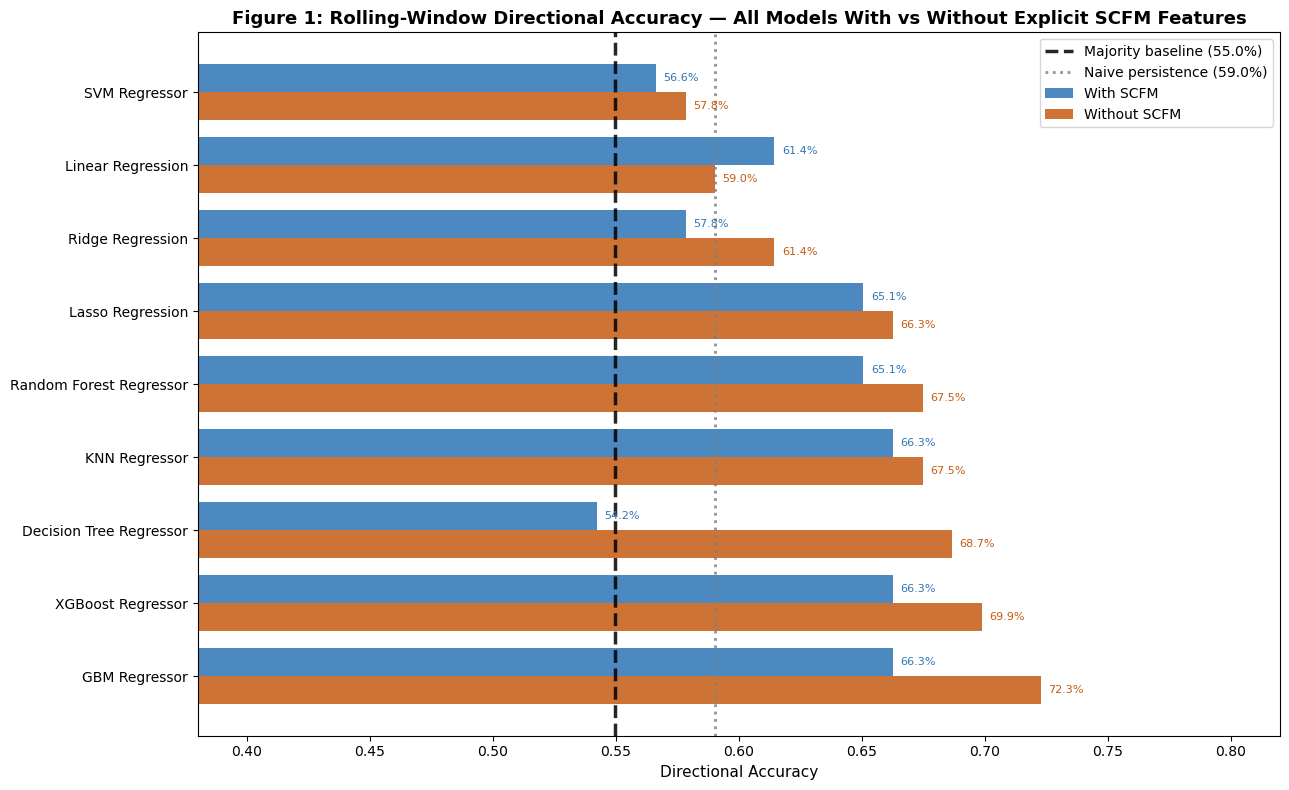

Saved: outputs/figure1_da_comparison.png


In [14]:
# ─────────────────────────────────────────────────────────────
# Figure 1: Directional Accuracy With vs Without SCFM
# Using an 83-row naive persistence baseline aligned to the model OOS window
# ─────────────────────────────────────────────────────────────

naive_bt = create_naive_persistence_baseline(df_model)
naive_baseline_da = naive_bt["correct_direction"].mean()

print(f"Naive persistence baseline OOS predictions: {len(naive_bt)}")
print(f"Naive persistence baseline DA: {naive_baseline_da:.2%}")
print(f"Expected OOS predictions: {len(df_model) - TRAIN_SIZE}")

assert len(naive_bt) == len(df_model) - TRAIN_SIZE

# Remove any baseline row if present
plot_df = comp_df[
    ~comp_df["model"].isin([
        "Naive baseline",
        "Majority-class baseline"
    ])
].copy()

# Plot
fig, ax = plt.subplots(figsize=(13, 8))

x = np.arange(len(plot_df))
w = 0.38

bars_with = ax.barh(
    x + w / 2,
    plot_df["da_with"],
    w,
    label="With SCFM",
    color="#2E75B6",
    alpha=0.85
)

bars_without = ax.barh(
    x - w / 2,
    plot_df["da_without"],
    w,
    label="Without SCFM",
    color="#C55A11",
    alpha=0.85
)

ax.axvline(
    baseline,
    color="black",
    linestyle="--",
    lw=2.5,
    alpha=0.85,
    label=f"Majority baseline ({baseline:.1%})"
)

ax.axvline(
    naive_baseline_da,
    color="gray",
    linestyle=":",
    lw=2.0,
    alpha=0.85,
    label=f"Naive persistence ({naive_baseline_da:.1%})"
)

ax.set_yticks(x)
ax.set_yticklabels(plot_df["model"], fontsize=10)

ax.set_xlabel("Directional Accuracy", fontsize=11)

ax.set_title(
    "Figure 1: Rolling-Window Directional Accuracy — "
    "All Models With vs Without Explicit SCFM Features",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=10)
ax.set_xlim(0.38, 0.82)

for bar, da in zip(bars_with, plot_df["da_with"]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{da:.1%}",
        va="center",
        fontsize=8,
        color="#2E75B6"
    )

for bar, da in zip(bars_without, plot_df["da_without"]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{da:.1%}",
        va="center",
        fontsize=8,
        color="#C55A11"
    )

plt.tight_layout()

plt.savefig(
    "outputs/figure1_da_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/figure1_da_comparison.png")


### 5.4 Best Model — Actual vs Predicted


Best model: GBM Regressor | DA: 72.29%


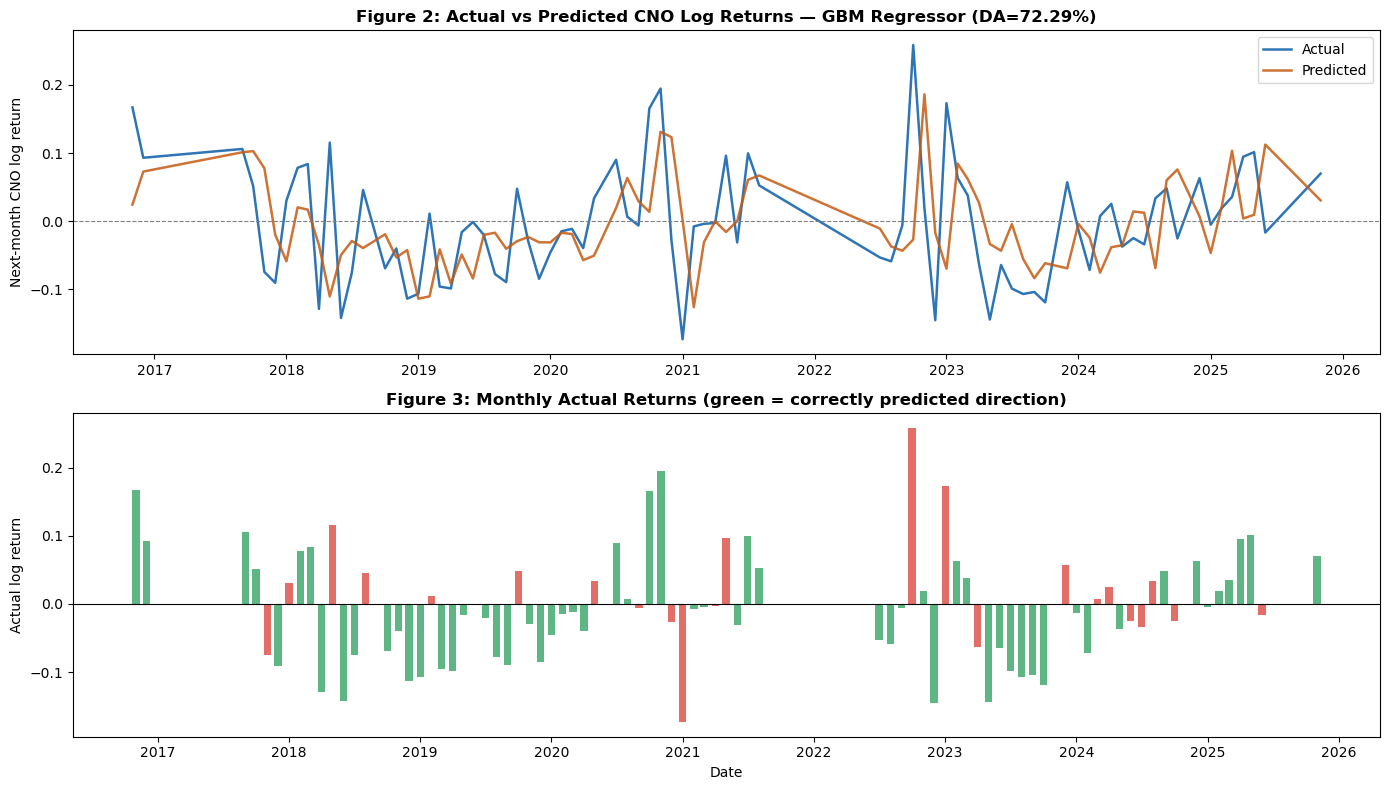

Saved: outputs/figure2_actual_vs_predicted.png


In [15]:
# Best model without SCFM (tree models prefer no explicit SCFM)
best_key  = max((m for m in MODEL_TYPES), key=lambda m: results_ns[m]["correct_direction"].mean())
best_name = model_labels[best_key]
bt_best   = results_ns[best_key]
best_da   = bt_best["correct_direction"].mean()

print(f"Best model: {best_name} | DA: {best_da:.2%}")

fig, axes = plt.subplots(2,1,figsize=(14,8))

axes[0].plot(bt_best["date"],bt_best["actual"],   label="Actual",   color="#2E75B6",lw=1.8)
axes[0].plot(bt_best["date"],bt_best["predicted"],label="Predicted",color="#C55A11",lw=1.8,alpha=0.85)
axes[0].axhline(0,color="gray",linestyle="--",lw=0.8)
axes[0].set_title(f"Figure 2: Actual vs Predicted CNO Log Returns — {best_name} (DA={best_da:.2%})",
                  fontsize=12,fontweight="bold")
axes[0].set_ylabel("Next-month CNO log return")
axes[0].legend()

correct_colors = ["#1a9850" if c else "#d73027" for c in bt_best["correct_direction"]]
axes[1].bar(bt_best["date"],bt_best["actual"],color=correct_colors,alpha=0.7,width=20)
axes[1].axhline(0,color="black",lw=0.8)
axes[1].set_title("Figure 3: Monthly Actual Returns (green = correctly predicted direction)",
                  fontsize=12,fontweight="bold")
axes[1].set_ylabel("Actual log return")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("outputs/figure2_actual_vs_predicted.png",dpi=150)
plt.show()
print("Saved: outputs/figure2_actual_vs_predicted.png")



### 5.5 Evaluator

In [16]:
def evaluate_model(bt, model_name):
    actual = bt["actual"].values
    predicted = bt["predicted"].values

    return {
        "model": model_name,
        "n_preds": len(bt),
        "DA": bt["correct_direction"].mean(),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
    }


In [17]:
eval_rows = []

for m in MODEL_TYPES:
    row = evaluate_model(results_ns[m], model_labels[m])
    eval_rows.append(row)


# Naive persistence baseline aligned to the same 83-month OOS window.
naive_baseline_df = create_naive_persistence_baseline(df_model)

naive_baseline_row = evaluate_model(
    naive_baseline_df,
    "Naive persistence baseline"
)

print(f"Naive persistence baseline OOS predictions: {len(naive_baseline_df)}")
assert len(naive_baseline_df) == len(df_model) - TRAIN_SIZE

eval_rows.append(naive_baseline_row)

eval_df = pd.DataFrame(eval_rows)

baseline_models = [
    "Naive persistence baseline",
]

model_mask = ~eval_df["model"].isin(baseline_models)

eval_df.loc[model_mask, "DA_rank"] = eval_df.loc[model_mask, "DA"].rank(
    ascending=False,
    method="min"
)

eval_df = eval_df.sort_values(
    ["DA", "RMSE"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)



Naive persistence baseline OOS predictions: 83


In [18]:
print("=" * 110)
print("  DIRECTION-ONLY MODEL RANKING")
naive_da = naive_baseline_row["DA"]
naive_rmse = naive_baseline_row["RMSE"]

print(f"  Naive baseline DA: {naive_da:.2%}")
print(f"  Naive baseline RMSE: {naive_rmse:.4f}")
print("=" * 110)

print(
    f"{'Model':35} | "
    f"{'DA':>8} | "
    f"{'MAE':>10} | "
    f"{'RMSE':>10} | "
    f"{'DA Rank':>8}"
)

print("─" * 110)

for _, r in eval_df.iterrows():

    mae_s = (
        f"{r['MAE']:.4f}"
        if pd.notna(r["MAE"])
        else "—"
    )

    rmse_s = (
        f"{r['RMSE']:.4f}"
        if pd.notna(r["RMSE"])
        else "—"
    )

    rank_s = (
        f"{int(r['DA_rank'])}"
        if pd.notna(r["DA_rank"])
        else "—"
    )

    print(
        f"{r['model']:35} | "
        f"{r['DA']:>8.2%} | "
        f"{mae_s:>10} | "
        f"{rmse_s:>10} | "
        f"{rank_s:>8}"
    )

print("─" * 110)

eval_df.to_csv(
    "outputs/direction_only_model_ranking.csv",
    index=False
)

eval_df


  DIRECTION-ONLY MODEL RANKING
  Naive baseline DA: 59.04%
  Naive baseline RMSE: 0.1056
Model                               |       DA |        MAE |       RMSE |  DA Rank
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
GBM Regressor                       |   72.29% |     0.0678 |     0.0881 |        1
XGBoost Regressor                   |   69.88% |     0.0631 |     0.0855 |        2
Decision Tree Regressor             |   68.67% |     0.0716 |     0.0924 |        3
Random Forest Regressor             |   67.47% |     0.0630 |     0.0840 |        4
KNN Regressor                       |   67.47% |     0.0667 |     0.0876 |        4
Lasso Regression                    |   66.27% |     0.0643 |     0.0850 |        6
Ridge Regression                    |   61.45% |     0.0797 |     0.1040 |        7
Naive persistence baseline          |   59.04% |     0.0791 |     0.1056 |        —
Linear Regression                   |   59.0

,model,n_preds,DA,MAE,RMSE,DA_rank
0,GBM Regressor,83,0.722892,0.067791,0.088091,1.0
1,XGBoost Regressor,83,0.698795,0.063126,0.085523,2.0
2,Decision Tree Regressor,83,0.686747,0.071554,0.092382,3.0
3,Random Forest Regressor,83,0.674699,0.062957,0.084008,4.0
4,KNN Regressor,83,0.674699,0.066696,0.087625,4.0
5,Lasso Regression,83,0.662651,0.064325,0.085042,6.0
6,Ridge Regression,83,0.614458,0.079661,0.103983,7.0
7,Naive persistence baseline,83,0.590361,0.079088,0.105550,NaN
8,Linear Regression,83,0.590361,0.097064,0.127373,8.0
9,SVM Regressor,83,0.578313,0.076425,0.103024,9.0


### 5.6 Classification Models — Direction-First Evaluation

The previous model family predicts the **magnitude** of next-month log returns and then converts the sign into BUY/SELL direction. This section adds true classification models that directly predict the binary direction target:

\[
y_t^{class} = \mathbb{1}(r_{t+1} > 0)
\]

The rolling-window discipline is unchanged: each fold trains only on the prior 48 months, fits preprocessing inside the fold, and predicts one out-of-sample month. Classification performance is evaluated using directional accuracy, balanced accuracy, precision, recall, F1, and ROC-AUC when probability scores are available.


In [19]:
CLASSIFIER_TYPES = [
    "logit", "knn_clf", "svm_clf", "dt_clf",
    "rf_clf", "gbm_clf", "xgb_clf"
]

classifier_labels = {
    "logit": "Logistic Regression",
    "knn_clf": "KNN Classifier",
    "svm_clf": "SVM Classifier",
    "dt_clf": "Decision Tree Classifier",
    "rf_clf": "Random Forest Classifier",
    "gbm_clf": "GBM Classifier",
    "xgb_clf": "XGBoost Classifier",
}


def get_classifier(model_type, y_tr):
    """Return a binary classifier with conservative settings for a small monthly dataset."""
    neg = int((y_tr == 0).sum())
    pos = int((y_tr == 1).sum())
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    models = {
        "logit": LogisticRegression(
            penalty="l2", C=1.0, solver="liblinear",
            class_weight="balanced", random_state=SEED
        ),
        "knn_clf": KNeighborsClassifier(
            n_neighbors=5, weights="distance"
        ),
        "svm_clf": SVC(
            kernel="rbf", C=1.0, gamma="scale",
            class_weight="balanced", probability=True,
            random_state=SEED
        ),
        "dt_clf": DecisionTreeClassifier(
            max_depth=3, min_samples_leaf=5,
            class_weight="balanced", random_state=SEED
        ),
        "rf_clf": RandomForestClassifier(
            n_estimators=300, max_depth=3, min_samples_leaf=5,
            class_weight="balanced_subsample", random_state=SEED,
            n_jobs=-1
        ),
        "gbm_clf": GradientBoostingClassifier(
            n_estimators=100, max_depth=2, learning_rate=0.05,
            subsample=0.8, random_state=SEED
        ),
        "xgb_clf": xgb.XGBClassifier(
            n_estimators=150, max_depth=2, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, min_child_weight=5,
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=SEED, verbosity=0
        ),
    }

    if model_type not in models:
        raise ValueError(f"Unknown classifier model_type: {model_type!r}")

    return models[model_type]


print("Classification model factory ready.")



Classification model factory ready.


In [20]:
def rolling_window_classification_backtest(
    df,
    target_col,
    feature_cols,
    model_type="logit",
    train_size=TRAIN_SIZE,
    test_size=1,
    step=1,
):
    """
    Rolling-window binary classification backtest.

    Target convention:
    - 1 = BUY / positive next-month CNO return
    - 0 = SELL / non-positive next-month CNO return
    """
    rows = []

    for start in range(0, len(df) - train_size - test_size + 1, step):
        train = df.iloc[start : start + train_size].copy()
        test = df.iloc[start + train_size : start + train_size + test_size].copy()

        X_tr = train[feature_cols].values
        X_te = test[feature_cols].values
        y_tr = train[target_col].values.astype(int)
        y_te = test[target_col].values.astype(int)

        if SCALE_ALL_FEATURES:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        model = get_classifier(model_type, y_tr)
        model.fit(X_tr, y_tr)

        pred_class = model.predict(X_te).astype(int)

        if hasattr(model, "predict_proba"):
            pred_prob = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, "decision_function"):
            raw_score = model.decision_function(X_te)
            pred_prob = 1 / (1 + np.exp(-raw_score))
        else:
            pred_prob = pred_class.astype(float)

        for i, pc in enumerate(pred_class):
            actual_return = test["target_next_cno_log_return"].iloc[i]
            actual_direction = int(y_te[i])

            rows.append({
                "date": test["date"].iloc[i],
                "actual": actual_return,
                "actual_direction": actual_direction,
                "pred_direction": int(pc),
                "pred_prob_up": float(pred_prob[i]),
                "predicted": 1 if int(pc) == 1 else -1,
                "signal": "BUY" if int(pc) == 1 else "SELL",
                "correct_direction": int(pc) == actual_direction,
            })

    return pd.DataFrame(rows)


print("Classification rolling-window backtest engine ready.")



Classification rolling-window backtest engine ready.


In [21]:
classification_results = {}
classification_results_ns = {}

for m in CLASSIFIER_TYPES:
    print(f"  {m:12}", end=" ")
    classification_results[m] = rolling_window_classification_backtest(
        df_model, classification_target_col, feature_cols, m, TRAIN_SIZE
    )
    classification_results_ns[m] = rolling_window_classification_backtest(
        df_model, classification_target_col, feature_cols_no_scfm, m, TRAIN_SIZE
    )

    da_w = classification_results[m]["correct_direction"].mean()
    da_wo = classification_results_ns[m]["correct_direction"].mean()
    print(f"with SCFM: {da_w:.2%} | without SCFM: {da_wo:.2%}")

print("\nAll classification models complete.")


  logit        with SCFM: 59.04% | without SCFM: 62.65%
  knn_clf      with SCFM: 61.45% | without SCFM: 63.86%
  svm_clf      with SCFM: 62.65% | without SCFM: 63.86%
  dt_clf       with SCFM: 65.06% | without SCFM: 67.47%
  rf_clf       with SCFM: 61.45% | without SCFM: 62.65%
  gbm_clf      with SCFM: 66.27% | without SCFM: 65.06%
  xgb_clf      with SCFM: 57.83% | without SCFM: 65.06%

All classification models complete.


In [22]:
def evaluate_classifier(bt, model_name):
    y_true = bt["actual_direction"].astype(int).values
    y_pred = bt["pred_direction"].astype(int).values
    y_prob = bt["pred_prob_up"].astype(float).values if "pred_prob_up" in bt.columns else None

    out = {
        "model": model_name,
        "n_preds": len(bt),
        "DA": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_buy": precision_score(y_true, y_pred, zero_division=0),
        "recall_buy": recall_score(y_true, y_pred, zero_division=0),
        "f1_buy": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out.update({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

    return out


clf_rows = [{
    "model": "Majority-class baseline",
    "family": "Baseline",
    "features": "constant",
    "n_preds": len(df_model) - TRAIN_SIZE,
    "DA": baseline,
    "balanced_accuracy": 0.5,
    "precision_buy": np.nan,
    "recall_buy": np.nan,
    "f1_buy": np.nan,
    "roc_auc": np.nan,
    "TN": np.nan, "FP": np.nan, "FN": np.nan, "TP": np.nan,
}]

for m in CLASSIFIER_TYPES:
    row_w = evaluate_classifier(classification_results[m], classifier_labels[m])
    row_w.update({"family": "Classifier", "features": "with SCFM"})
    clf_rows.append(row_w)

    row_ns = evaluate_classifier(classification_results_ns[m], classifier_labels[m])
    row_ns.update({"family": "Classifier", "features": "without SCFM"})
    clf_rows.append(row_ns)

classification_comp_df = (
    pd.DataFrame(clf_rows)
    .sort_values(["DA", "balanced_accuracy", "roc_auc"], ascending=[False, False, False], na_position="last")
    .reset_index(drop=True)
)

print("=" * 120)
print("  CLASSIFICATION MODEL RANKING")
print("=" * 120)
print(
    f"{'Model':30} | {'Features':12} | {'DA':>8} | {'BalAcc':>8} | "
    f"{'F1(BUY)':>8} | {'AUC':>8} | {'TP':>4} | {'TN':>4} | {'FP':>4} | {'FN':>4}"
)
print("─" * 120)

for _, r in classification_comp_df.iterrows():
    auc_s = f"{r['roc_auc']:.3f}" if pd.notna(r["roc_auc"]) else "—"
    f1_s = f"{r['f1_buy']:.3f}" if pd.notna(r["f1_buy"]) else "—"
    tp_s = f"{int(r['TP'])}" if pd.notna(r["TP"]) else "—"
    tn_s = f"{int(r['TN'])}" if pd.notna(r["TN"]) else "—"
    fp_s = f"{int(r['FP'])}" if pd.notna(r["FP"]) else "—"
    fn_s = f"{int(r['FN'])}" if pd.notna(r["FN"]) else "—"

    print(
        f"{r['model']:30} | {r['features']:12} | {r['DA']:>8.2%} | "
        f"{r['balanced_accuracy']:>8.2%} | {f1_s:>8} | {auc_s:>8} | "
        f"{tp_s:>4} | {tn_s:>4} | {fp_s:>4} | {fn_s:>4}"
    )

classification_comp_df.to_csv("outputs/classification_model_comparison.csv", index=False)

for m, bt in classification_results.items():
    bt.to_csv(f"outputs/classification_backtest_with_scfm_{m}.csv", index=False)
for m, bt in classification_results_ns.items():
    bt.to_csv(f"outputs/classification_backtest_no_scfm_{m}.csv", index=False)

classification_comp_df



  CLASSIFICATION MODEL RANKING
Model                          | Features     |       DA |   BalAcc |  F1(BUY) |      AUC |   TP |   TN |   FP |   FN
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Decision Tree Classifier       | without SCFM |   67.47% |   65.68% |    0.585 |    0.668 |   19 |   37 |   11 |   16
GBM Classifier                 | with SCFM    |   66.27% |   65.42% |    0.600 |    0.640 |   21 |   34 |   14 |   14
XGBoost Classifier             | without SCFM |   65.06% |   65.54% |    0.623 |    0.620 |   24 |   30 |   18 |   11
GBM Classifier                 | without SCFM |   65.06% |   63.99% |    0.580 |    0.637 |   20 |   34 |   14 |   15
Decision Tree Classifier       | with SCFM    |   65.06% |   62.83% |    0.540 |    0.660 |   17 |   37 |   11 |   18
SVM Classifier                 | without SCFM |   63.86% |   62.95% |    0.571 |    0.487 |   20 |   33 |   15 |   15
KNN Classifier        

,model,family,features,n_preds,DA,balanced_accuracy,precision_buy,recall_buy,f1_buy,roc_auc,TN,FP,FN,TP
0,Decision Tree Classifier,Classifier,without SCFM,83,0.674699,0.656845,0.633333,0.542857,0.584615,0.668155,37.0,11.0,16.0,19.0
1,GBM Classifier,Classifier,with SCFM,83,0.662651,0.654167,0.600000,0.600000,0.600000,0.639881,34.0,14.0,14.0,21.0
2,XGBoost Classifier,Classifier,without SCFM,83,0.650602,0.655357,0.571429,0.685714,0.623377,0.620238,30.0,18.0,11.0,24.0
3,GBM Classifier,Classifier,without SCFM,83,0.650602,0.639881,0.588235,0.571429,0.579710,0.636905,34.0,14.0,15.0,20.0
4,Decision Tree Classifier,Classifier,with SCFM,83,0.650602,0.628274,0.607143,0.485714,0.539683,0.659821,37.0,11.0,18.0,17.0
5,SVM Classifier,Classifier,without SCFM,83,0.638554,0.629464,0.571429,0.571429,0.571429,0.487500,33.0,15.0,15.0,20.0
6,KNN Classifier,Classifier,without SCFM,83,0.638554,0.625595,0.575758,0.542857,0.558824,0.622024,34.0,14.0,16.0,19.0
7,Random Forest Classifier,Classifier,without SCFM,83,0.626506,0.630655,0.547619,0.657143,0.597403,0.644643,29.0,19.0,12.0,23.0
8,SVM Classifier,Classifier,with SCFM,83,0.626506,0.622917,0.552632,0.600000,0.575342,0.490774,31.0,17.0,14.0,21.0
9,Logistic Regression,Classifier,without SCFM,83,0.626506,0.599702,0.576923,0.428571,0.491803,0.608929,37.0,11.0,20.0,15.0


Best classifier: Decision Tree Classifier (without SCFM) | DA=67.47%
Balanced accuracy: 65.68% | F1(BUY): 0.585


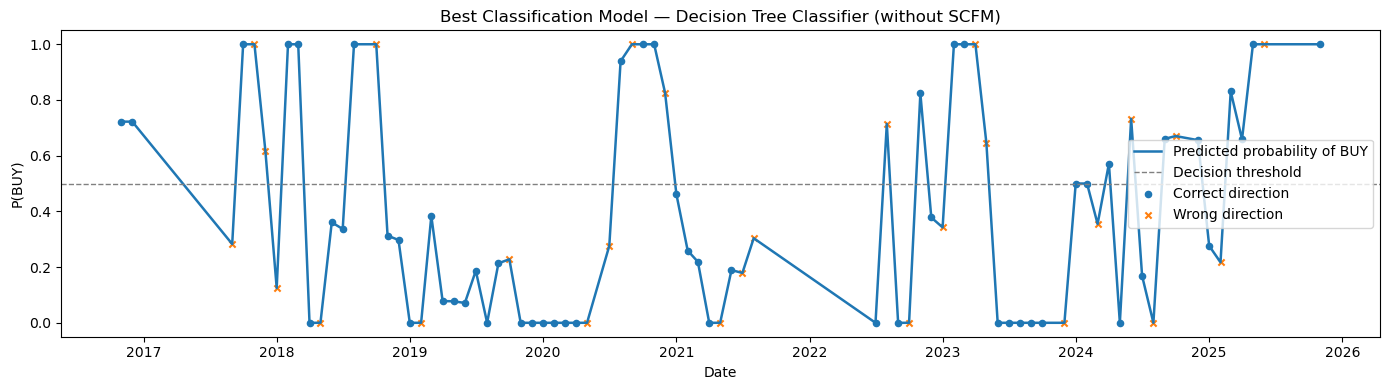

Saved: outputs/figure_classification_best_model_probabilities.png


In [23]:
# Best pure classification model by directional accuracy.
best_clf_row = classification_comp_df[classification_comp_df["family"] == "Classifier"].iloc[0]
best_clf_name = best_clf_row["model"]
best_clf_features = best_clf_row["features"]

best_clf_key = {v: k for k, v in classifier_labels.items()}[best_clf_name]
best_clf_bt = (
    classification_results[best_clf_key]
    if best_clf_features == "with SCFM"
    else classification_results_ns[best_clf_key]
)

print(f"Best classifier: {best_clf_name} ({best_clf_features}) | DA={best_clf_row['DA']:.2%}")
print(f"Balanced accuracy: {best_clf_row['balanced_accuracy']:.2%} | F1(BUY): {best_clf_row['f1_buy']:.3f}")

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(best_clf_bt["date"], best_clf_bt["pred_prob_up"], lw=1.8, label="Predicted probability of BUY")
ax.axhline(0.5, color="gray", linestyle="--", lw=1.0, label="Decision threshold")

correct = best_clf_bt["correct_direction"].astype(bool)
ax.scatter(
    best_clf_bt.loc[correct, "date"],
    best_clf_bt.loc[correct, "pred_prob_up"],
    s=20,
    label="Correct direction"
)
ax.scatter(
    best_clf_bt.loc[~correct, "date"],
    best_clf_bt.loc[~correct, "pred_prob_up"],
    s=20,
    marker="x",
    label="Wrong direction"
)

ax.set_title(f"Best Classification Model — {best_clf_name} ({best_clf_features})")
ax.set_ylabel("P(BUY)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figure_classification_best_model_probabilities.png", dpi=150)
plt.show()

print("Saved: outputs/figure_classification_best_model_probabilities.png")



### 5.6 Feature Importance


In [24]:
# Fold-averaged XGBoost feature importance for interpretability.
# This avoids fitting an interpretability model on the full sample, which would
# use test-period labels and contaminate out-of-sample claims.
importance_rows = []

for start in range(0, len(df_model) - TRAIN_SIZE, 1):
    train = df_model.iloc[start : start + TRAIN_SIZE].copy()
    test  = df_model.iloc[start + TRAIN_SIZE : start + TRAIN_SIZE + 1].copy()


    X_tr = train[feature_cols_no_scfm]
    y_tr = train[target_col]

    fold_xgb = xgb.XGBRegressor(
        n_estimators=150, max_depth=2, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0,
        min_child_weight=5, objective="reg:squarederror",
        random_state=SEED, verbosity=0
    )
    fold_xgb.fit(X_tr, y_tr)

    importance_rows.append(
        pd.DataFrame({
            "fold_start": start,
            "feature": feature_cols_no_scfm,
            "importance": fold_xgb.feature_importances_,
        })
    )

imp_folds = pd.concat(importance_rows, ignore_index=True)
imp_df = (imp_folds.groupby("feature", as_index=False)["importance"]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean":"importance", "std":"importance_std"})
          .sort_values("importance", ascending=False)
          .reset_index(drop=True))

imp_df.to_csv("outputs/feature_importance_fold_averaged.csv", index=False)
print("Top 15 fold-averaged no-SCFM XGBoost features:")
print(imp_df.head(15).to_string(index=False))

cpo_imp   = imp_df[imp_df["feature"].str.contains("cpo")]["importance"].sum()
oni_imp   = imp_df[imp_df["feature"].str.contains("oni")]["importance"].sum()
copra_imp = imp_df[imp_df["feature"].str.contains("copra")]["importance"].sum()
fx_imp    = imp_df[imp_df["feature"].str.contains("usd_php")]["importance"].sum()
prod_imp  = imp_df[imp_df["feature"].str.contains("coconut_prod")]["importance"].sum()

print("\nFeature group importances, averaged across rolling training folds:")
print(f"  CPO weekly lags:       {cpo_imp:.4f}")
print(f"  Copra farmgate lags:   {copra_imp:.4f}")
print(f"  USD/PHP lags:          {fx_imp:.4f}")
print(f"  Coconut production:    {prod_imp:.4f}")
print(f"  ONI:                   {oni_imp:.4f}")
print("\nInterpret these as descriptive rolling-fold importances, not causal effects.")



Top 15 fold-averaged no-SCFM XGBoost features:
 index             feature  importance  importance_std
     4 copra_farmgate_lag3    0.088962        0.042551
    13        usd_php_lag3    0.083784        0.040458
     2 copra_farmgate_lag1    0.081658        0.030181
    10            oni_lag1    0.080946        0.031368
     5 copra_farmgate_lag4    0.077822        0.024028
    14        usd_php_lag4    0.070938        0.022964
    11        usd_php_lag1    0.067345        0.014359
     3 copra_farmgate_lag2    0.061452        0.026232
    12        usd_php_lag2    0.061187        0.011234
     6      cpo_price_lag1    0.058229        0.013310
     7      cpo_price_lag2    0.057806        0.020793
     1   coconut_prod_lag6    0.053678        0.015940
     0   coconut_prod_lag5    0.052941        0.023491
     8      cpo_price_lag3    0.052496        0.013321
     9      cpo_price_lag4    0.050756        0.007854

Feature group importances, averaged across rolling training folds:
  CPO

### 5.7 Dimensionality Reduction — SVD and PCA

We apply **Truncated SVD** and **PCA** to the full feature set. Full-sample component plots are descriptive only; performance comparisons below use fold-specific scaler/reducer fits inside the rolling backtest.

Goals:
- Understand how much variance each component explains
- Check whether the feature space is genuinely high-dimensional or already low-rank
- Feed the reduced representation into the rolling-window backtest and compare DA to the raw-feature models
- Identify which original features load most heavily onto the top components (SCFM? CPO? ONI?)


In [25]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.utils.extmath import randomized_svd

# ── Prepare feature matrix ────────────────────────────────────────────────────
# StandardScaler here is for the exploration/loading analysis only.
# Inside the rolling backtest we refit scaler + reducer per fold — no leakage.
scaler_full = StandardScaler()
X_scaled    = scaler_full.fit_transform(df_model[feature_cols].values)
n_features  = X_scaled.shape[1]
n_svd_show  = min(n_features, 20)

print(f"Feature matrix (with SCFM): {X_scaled.shape}")
print(f"Inspecting first {n_svd_show} components")



Feature matrix (with SCFM): (131, 19)
Inspecting first 19 components


In [26]:
# ── Truncated SVD ─────────────────────────────────────────────────────────────
svd = TruncatedSVD(n_components=n_svd_show, random_state=SEED)
svd.fit(X_scaled)
svd_cumvar = np.cumsum(svd.explained_variance_ratio_)

print("SVD cumulative variance thresholds:")
for thresh in [0.80, 0.90, 0.95]:
    k = int(np.searchsorted(svd_cumvar, thresh)) + 1
    print(f"  {k:2d} components -> {thresh:.0%}")

U, Sigma, Vt = randomized_svd(X_scaled, n_components=n_svd_show, random_state=SEED)
print(f"\nTop-5 singular values: {np.round(Sigma[:5], 2)}")



SVD cumulative variance thresholds:
   4 components -> 80%
   5 components -> 90%
   7 components -> 95%

Top-5 singular values: [29.69 23.08 20.53 16.38 11.69]


PCA cumulative variance thresholds:
   4 components -> 80%
   5 components -> 90%
   7 components -> 95%


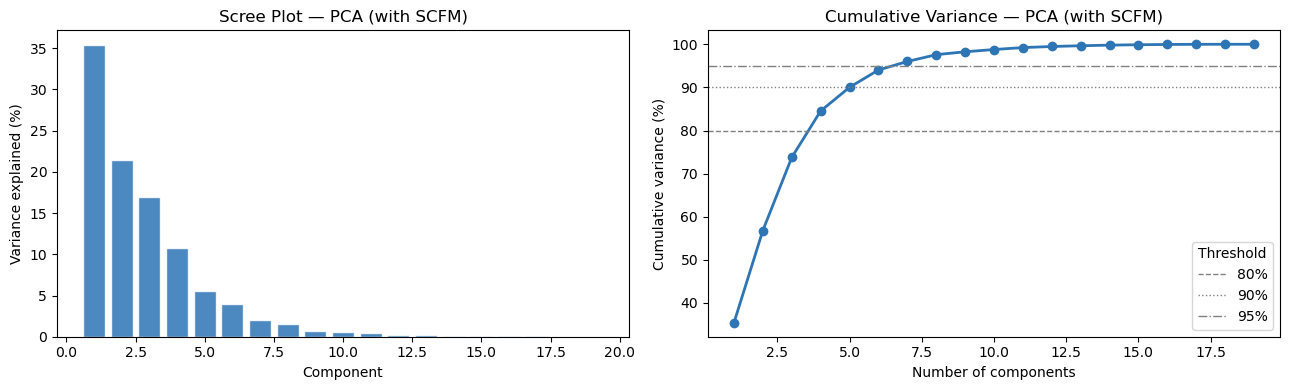

In [27]:
# ── PCA full fit + scree plot ─────────────────────────────────────────────────
pca_full   = PCA(random_state=SEED)
pca_full.fit(X_scaled)
pca_var    = pca_full.explained_variance_ratio_
pca_cumvar = np.cumsum(pca_var)

print("PCA cumulative variance thresholds:")
for thresh in [0.80, 0.90, 0.95]:
    k = int(np.searchsorted(pca_cumvar, thresh)) + 1
    print(f"  {k:2d} components -> {thresh:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_svd_show+1), pca_var[:n_svd_show]*100,
            color="#2E75B6", alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree Plot — PCA (with SCFM)")

axes[1].plot(range(1, n_svd_show+1), pca_cumvar[:n_svd_show]*100,
             marker="o", color="#2E75B6", linewidth=2)
for thresh, ls, label in [(0.80,"--","80%"),(0.90,":","90%"),(0.95,"-.","95%")]:
    axes[1].axhline(thresh*100, linestyle=ls, color="gray", linewidth=1, label=label)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative Variance — PCA (with SCFM)")
axes[1].legend(title="Threshold")

plt.tight_layout()
plt.savefig("outputs/pca_scree_plot.png", dpi=300)
plt.show()



Top 5 feature loadings per component:

  PC1: copra_farmgate_lag2 (+0.351) | copra_farmgate_lag1 (+0.347) | copra_farmgate_lag3 (+0.344) | copra_farmgate_lag4 (+0.329) | cpo_price_lag1 (+0.277)
  PC2: usd_php_lag2 (+0.422) | usd_php_lag3 (+0.422) | usd_php_lag4 (+0.420) | usd_php_lag1 (+0.419) | scfm_mean6 (+0.235)
  PC3: scfm_lag1 (+0.405) | scfm (+0.402) | scfm_mean6 (+0.362) | cpo_price_lag4 (+0.334) | cpo_price_lag3 (+0.311)
  PC4: scfm_dev (+0.544) | coconut_prod_lag6 (-0.451) | coconut_prod_lag5 (-0.412) | scfm (+0.353) | scfm_lag1 (+0.257)
  PC5: coconut_prod_lag5 (+0.532) | coconut_prod_lag6 (+0.461) | scfm_dev (+0.342) | oni_lag1 (-0.253) | cpo_price_lag4 (-0.247)


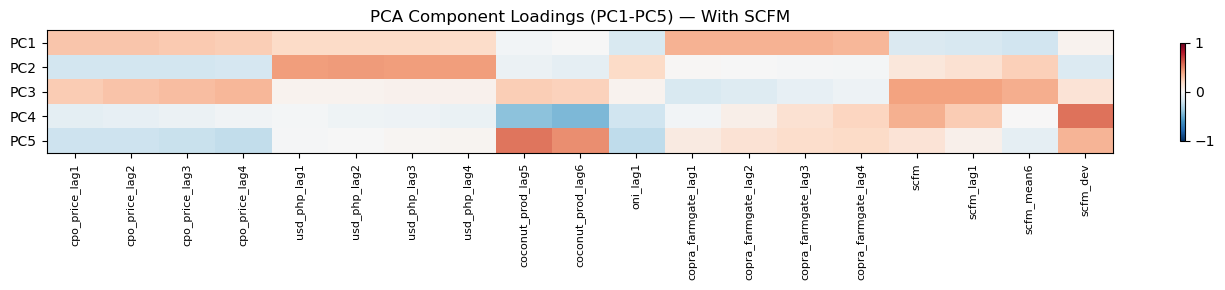

In [28]:
# ── Component loadings — which features dominate each PC ─────────────────────
n_show   = 5
loadings = pd.DataFrame(
    pca_full.components_[:n_show],
    columns=feature_cols,
    index=["PC" + str(i+1) for i in range(n_show)]
)

print("Top 5 feature loadings per component:\n")
for pc in loadings.index:
    top5  = loadings.loc[pc].abs().nlargest(5)
    signs = loadings.loc[pc][top5.index]
    parts = ["{} ({:+.3f})".format(f, v) for f, v in signs.items()]
    print("  {}: {}".format(pc, " | ".join(parts)))

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(loadings.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=8)
ax.set_yticks(range(n_show))
ax.set_yticklabels(["PC" + str(i+1) for i in range(n_show)])
ax.set_title("PCA Component Loadings (PC1-PC5) — With SCFM")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("outputs/pca_loadings_heatmap.png", dpi=300)
plt.show()



In [29]:
# ── Choose n_components for backtest ─────────────────────────────────────────
N_PCA_COMPONENTS = int(np.searchsorted(pca_cumvar, 0.95)) + 1
print("Using {} components (>= 95% variance)".format(N_PCA_COMPONENTS))

def rolling_window_backtest_pca(
    df, target_col, feature_cols,
    model_type="xgb", train_size=48,
    test_size=1, step=1,
    n_components=N_PCA_COMPONENTS,
    use_svd=False,
):
    """
    Rolling-window backtest with PCA/SVD fitted inside each training fold.

    This preserves out-of-sample discipline:
    - StandardScaler is fitted on the training window only.
    - PCA/SVD is fitted on the training window only.
    """
    rows = []

    for start in range(0, len(df) - train_size - test_size + 1, step):
        train = df.iloc[start:start + train_size].copy()
        test  = df.iloc[start + train_size:start + train_size + test_size].copy()

        X_tr_raw = train[feature_cols].values
        X_te_raw = test[feature_cols].values

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_te_sc = scaler.transform(X_te_raw)

        max_components = min(n_components, X_tr_sc.shape[0], X_tr_sc.shape[1])
        if use_svd:
            reducer = TruncatedSVD(n_components=max_components, random_state=SEED)
        else:
            reducer = PCA(n_components=max_components, random_state=SEED)

        X_tr = reducer.fit_transform(X_tr_sc)
        X_te = reducer.transform(X_te_sc)
        y_tr = train[target_col].values

        model = get_model(model_type, y_tr)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        for i, pv in enumerate(preds):
            raw_actual = test[target_col].iloc[i]
            actual_direction = int(raw_actual > 0)

            pred_direction = int(pv > 0)

            rows.append({
                "date": test["date"].iloc[i],
                "actual": raw_actual,
                "predicted": pv,
                "actual_direction": actual_direction,
                "pred_direction": pred_direction,
                "correct_direction": pred_direction == actual_direction,
            })

    out = pd.DataFrame(rows)
    out["error"] = out["predicted"] - out["actual"]
    out["abs_error"] = out["error"].abs()
    out["squared_error"] = out["error"] ** 2

    return out

print("PCA/SVD rolling backtest engine ready.")



Using 7 components (>= 95% variance)
PCA/SVD rolling backtest engine ready.


In [30]:
results_pca = {}
results_svd = {}

for m in MODEL_TYPES:
    print("  {:12}".format(m), end=" ")
    results_pca[m] = rolling_window_backtest_pca(
        df_model, target_col, feature_cols, m, TRAIN_SIZE, use_svd=False)
    results_svd[m] = rolling_window_backtest_pca(
        df_model, target_col, feature_cols, m, TRAIN_SIZE, use_svd=True)
    da_raw = results[m]["correct_direction"].mean()
    da_pca = results_pca[m]["correct_direction"].mean()
    da_svd = results_svd[m]["correct_direction"].mean()
    print("raw: {:.2%} | PCA: {:.2%} | SVD: {:.2%}".format(da_raw, da_pca, da_svd))

print("\nAll PCA/SVD backtests complete.")



  linear       raw: 61.45% | PCA: 61.45% | SVD: 61.45%
  ridge        raw: 57.83% | PCA: 62.65% | SVD: 62.65%
  lasso        raw: 65.06% | PCA: 66.27% | SVD: 66.27%
  knn_reg      raw: 66.27% | PCA: 62.65% | SVD: 62.65%
  svm_reg      raw: 56.63% | PCA: 60.24% | SVD: 60.24%
  dt_reg       raw: 54.22% | PCA: 57.83% | SVD: 57.83%
  rf_reg       raw: 65.06% | PCA: 60.24% | SVD: 60.24%
  gbm_reg      raw: 66.27% | PCA: 50.60% | SVD: 50.60%
  xgb          raw: 66.27% | PCA: 56.63% | SVD: 56.63%

All PCA/SVD backtests complete.


In [31]:
# ── PCA/SVD backtests without SCFM ────────────────────────────────────────────
results_pca_ns = {}
results_svd_ns = {}

for m in MODEL_TYPES:
    print("  {:12}".format(m), end=" ")

    results_pca_ns[m] = rolling_window_backtest_pca(
        df_model, target_col, feature_cols_no_scfm, m, TRAIN_SIZE, use_svd=False
    )

    results_svd_ns[m] = rolling_window_backtest_pca(
        df_model, target_col, feature_cols_no_scfm, m, TRAIN_SIZE, use_svd=True
    )

    da_raw_ns = results_ns[m]["correct_direction"].mean()
    da_pca_ns = results_pca_ns[m]["correct_direction"].mean()
    da_svd_ns = results_svd_ns[m]["correct_direction"].mean()

    print("raw(no): {:.2%} | PCA(no): {:.2%} | SVD(no): {:.2%}".format(
        da_raw_ns, da_pca_ns, da_svd_ns
    ))

print("\nAll PCA/SVD no-SCFM backtests complete.")



  linear       raw(no): 59.04% | PCA(no): 60.24% | SVD(no): 60.24%
  ridge        raw(no): 61.45% | PCA(no): 60.24% | SVD(no): 60.24%
  lasso        raw(no): 66.27% | PCA(no): 60.24% | SVD(no): 60.24%
  knn_reg      raw(no): 67.47% | PCA(no): 68.67% | SVD(no): 68.67%
  svm_reg      raw(no): 57.83% | PCA(no): 61.45% | SVD(no): 61.45%
  dt_reg       raw(no): 68.67% | PCA(no): 59.04% | SVD(no): 59.04%
  rf_reg       raw(no): 67.47% | PCA(no): 61.45% | SVD(no): 61.45%
  gbm_reg      raw(no): 72.29% | PCA(no): 56.63% | SVD(no): 56.63%
  xgb          raw(no): 69.88% | PCA(no): 67.47% | SVD(no): 67.47%

All PCA/SVD no-SCFM backtests complete.


In [32]:
dim_rows_ns = []

for m in MODEL_TYPES:
    raw_metrics = evaluate_model(results_ns[m], model_labels[m])
    pca_metrics = evaluate_model(results_pca_ns[m], model_labels[m])
    svd_metrics = evaluate_model(results_svd_ns[m], model_labels[m])

    dim_rows_ns.append({
        "model": model_labels[m],

        # Direction
        "DA Raw": raw_metrics["DA"],
        "DA PCA": pca_metrics["DA"],
        "DA SVD": svd_metrics["DA"],

        # Magnitude (error)
        "RMSE Raw": raw_metrics["RMSE"],
        "RMSE PCA": pca_metrics["RMSE"],
        "RMSE SVD": svd_metrics["RMSE"],

        "MAE Raw": raw_metrics["MAE"],
        "MAE PCA": pca_metrics["MAE"],
        "MAE SVD": svd_metrics["MAE"],

        # Improvements
        "ΔDA PCA": pca_metrics["DA"] - raw_metrics["DA"],
        "ΔDA SVD": svd_metrics["DA"] - raw_metrics["DA"],
    })

dim_comp_df_ns = pd.DataFrame(dim_rows_ns)

dim_comp_df_ns


,model,DA Raw,DA PCA,DA SVD,RMSE Raw,RMSE PCA,RMSE SVD,MAE Raw,MAE PCA,MAE SVD,ΔDA PCA,ΔDA SVD
0,Linear Regression,0.590361,0.602410,0.602410,0.127373,0.098983,0.098983,0.097064,0.072256,0.072256,0.012048,0.012048
1,Ridge Regression,0.614458,0.602410,0.602410,0.103983,0.097584,0.097584,0.079661,0.071179,0.071179,-0.012048,-0.012048
2,Lasso Regression,0.662651,0.602410,0.602410,0.085042,0.089122,0.089122,0.064325,0.066619,0.066619,-0.060241,-0.060241
3,KNN Regressor,0.674699,0.686747,0.686747,0.087625,0.087613,0.087613,0.066696,0.067474,0.067474,0.012048,0.012048
4,SVM Regressor,0.578313,0.614458,0.614458,0.103024,0.105239,0.105239,0.076425,0.078183,0.078183,0.036145,0.036145
5,Decision Tree Regressor,0.686747,0.590361,0.590361,0.092382,0.100429,0.100429,0.071554,0.075326,0.075326,-0.096386,-0.096386
6,Random Forest Regressor,0.674699,0.614458,0.614458,0.084008,0.085137,0.085137,0.062957,0.065113,0.065113,-0.060241,-0.060241
7,GBM Regressor,0.722892,0.566265,0.566265,0.088091,0.098640,0.098640,0.067791,0.074899,0.074899,-0.156627,-0.156627
8,XGBoost Regressor,0.698795,0.674699,0.674699,0.085523,0.089101,0.089101,0.063126,0.068122,0.068122,-0.024096,-0.024096


In [33]:
# ── Comparison table: Raw vs PCA vs SVD ──────────────────────────────────────
dim_rows = []

for m in MODEL_TYPES:
    raw_metrics = evaluate_model(results[m], model_labels[m])
    pca_metrics = evaluate_model(results_pca[m], model_labels[m])
    svd_metrics = evaluate_model(results_svd[m], model_labels[m])

    dim_rows.append({
        "model": model_labels[m],

        # Direction
        "DA Raw": raw_metrics["DA"],
        "DA PCA": pca_metrics["DA"],
        "DA SVD": svd_metrics["DA"],

        # Direction improvement
        "ΔDA PCA": pca_metrics["DA"] - raw_metrics["DA"],
        "ΔDA SVD": svd_metrics["DA"] - raw_metrics["DA"],

        # Magnitude diagnostics only
        "RMSE Raw": raw_metrics["RMSE"],
        "RMSE PCA": pca_metrics["RMSE"],
        "RMSE SVD": svd_metrics["RMSE"],

        "MAE Raw": raw_metrics["MAE"],
        "MAE PCA": pca_metrics["MAE"],
        "MAE SVD": svd_metrics["MAE"],

        # Direction-only interpretation
        "PCA helps DA": "yes" if pca_metrics["DA"] > raw_metrics["DA"] else "no",
        "SVD helps DA": "yes" if svd_metrics["DA"] > raw_metrics["DA"] else "no",
    })

dim_comp_df = pd.DataFrame(dim_rows)

# Rank only by best DA across Raw/PCA/SVD
dim_comp_df["Best DA"] = dim_comp_df[
    ["DA Raw", "DA PCA", "DA SVD"]
].max(axis=1)

dim_comp_df["Best version"] = dim_comp_df[
    ["DA Raw", "DA PCA", "DA SVD"]
].idxmax(axis=1).str.replace("DA ", "")

dim_comp_df["DA Rank"] = dim_comp_df["Best DA"].rank(
    ascending=False,
    method="min"
).astype(int)

dim_comp_df = dim_comp_df.sort_values(
    ["DA Rank", "Best DA"],
    ascending=[True, False]
).reset_index(drop=True)


# ── Save full table ──────────────────────────────────────────────────────────
dim_comp_df.to_csv(
    "outputs/dimensionality_comparison_direction_ranked.csv",
    index=False
)


# ── Clean display table ──────────────────────────────────────────────────────
display_df = dim_comp_df[[
    "model",
    "DA Raw", "DA PCA", "DA SVD",
    "ΔDA PCA", "ΔDA SVD",
    "Best version", "Best DA", "DA Rank",
    "RMSE Raw", "RMSE PCA", "RMSE SVD",
    "MAE Raw", "MAE PCA", "MAE SVD",
]].copy()

for col in display_df.columns:
    if "DA" in col:
        display_df[col] = (display_df[col] * 100).round(2)
    elif "RMSE" in col or "MAE" in col:
        display_df[col] = display_df[col].round(4)

print("Components: {} | Baseline DA: {:.2%}".format(
    N_PCA_COMPONENTS, baseline
))

display_df


Components: 7 | Baseline DA: 54.96%


,model,DA Raw,DA PCA,DA SVD,ΔDA PCA,ΔDA SVD,Best version,Best DA,DA Rank,RMSE Raw,RMSE PCA,RMSE SVD,MAE Raw,MAE PCA,MAE SVD
0,Lasso Regression,65.06,66.27,66.27,1.20,1.20,PCA,66.27,100,0.0819,0.0827,0.0827,0.0621,0.0628,0.0628
1,KNN Regressor,66.27,62.65,62.65,-3.61,-3.61,Raw,66.27,100,0.0878,0.0856,0.0856,0.0668,0.0659,0.0659
2,GBM Regressor,66.27,50.60,50.60,-15.66,-15.66,Raw,66.27,100,0.0898,0.0992,0.0992,0.0690,0.0768,0.0768
3,XGBoost Regressor,66.27,56.63,56.63,-9.64,-9.64,Raw,66.27,100,0.0849,0.0862,0.0862,0.0633,0.0666,0.0666
4,Random Forest Regressor,65.06,60.24,60.24,-4.82,-4.82,Raw,65.06,500,0.0844,0.0840,0.0840,0.0636,0.0652,0.0652
5,Ridge Regression,57.83,62.65,62.65,4.82,4.82,PCA,62.65,600,0.1039,0.0897,0.0897,0.0780,0.0673,0.0673
6,Linear Regression,61.45,61.45,61.45,0.00,0.00,Raw,61.45,700,0.1318,0.0905,0.0905,0.0939,0.0679,0.0679
7,SVM Regressor,56.63,60.24,60.24,3.61,3.61,PCA,60.24,800,0.1034,0.1072,0.1072,0.0766,0.0806,0.0806
8,Decision Tree Regressor,54.22,57.83,57.83,3.61,3.61,PCA,57.83,900,0.0972,0.0999,0.0999,0.0757,0.0779,0.0779


In [34]:
# ── Save all PCA/SVD outputs ──────────────────────────────────────────────────
dim_comp_df.to_csv("outputs/pca_svd_model_comparison.csv", index=False)

pd.DataFrame(
    pca_full.components_,
    columns=feature_cols,
    index=["PC"+str(i+1) for i in range(len(pca_full.components_))]
).to_csv("outputs/pca_component_loadings.csv")

pd.DataFrame({
    "component":                range(1, len(pca_var)+1),
    "explained_variance_ratio": pca_var,
    "cumulative_variance":      pca_cumvar,
    "singular_value":           np.append(Sigma, [np.nan]*(len(pca_var)-len(Sigma)))
}).to_csv("outputs/pca_variance_table.csv", index=False)

for m, bt in results_pca.items():
    bt.to_csv("outputs/backtest_pca_{}.csv".format(m), index=False)
for m, bt in results_svd.items():
    bt.to_csv("outputs/backtest_svd_{}.csv".format(m), index=False)

print("Saved:")
for fname in ["pca_svd_model_comparison.csv","pca_component_loadings.csv",
              "pca_variance_table.csv","pca_scree_plot.png",
              "pca_loadings_heatmap.png","pca_svd_da_comparison.png","pca_2d_scatter.png"]:
    print("  outputs/{}".format(fname))
print("  outputs/backtest_pca_<model>.csv  (x15)")
print("  outputs/backtest_svd_<model>.csv  (x15)")



Saved:
  outputs/pca_svd_model_comparison.csv
  outputs/pca_component_loadings.csv
  outputs/pca_variance_table.csv
  outputs/pca_scree_plot.png
  outputs/pca_loadings_heatmap.png
  outputs/pca_svd_da_comparison.png
  outputs/pca_2d_scatter.png
  outputs/backtest_pca_<model>.csv  (x15)
  outputs/backtest_svd_<model>.csv  (x15)


### 5.8 Statistical Significance — Block Bootstrap


In [35]:
def block_bootstrap_da(correct_direction, n_boot=10000, block_size=6,
                       baseline_da=None, seed=42):
    rng = np.random.default_rng(seed)

    arr = correct_direction.values.astype(float)
    n = len(arr)
    obs = arr.mean()

    if baseline_da is None:
        baseline_da = max(obs, 1 - obs)

    boot = []

    for _ in range(n_boot):
        idx = []

        while len(idx) < n:
            s = rng.integers(0, n)
            idx.extend(arr[s:s + block_size].tolist())

        boot.append(np.array(idx[:n]).mean())

    boot = np.array(boot)

    # One-sided bootstrap p-value against baseline DA.
    # Null is centered at baseline_da by shifting each bootstrap replicate.
    p = ((boot - obs + baseline_da) >= obs).mean()

    return obs, baseline_da, np.percentile(boot, 2.5), np.percentile(boot, 97.5), p


# Use the model keys that actually exist in results_ns.
MODEL_TYPES_BOOT = list(results_ns.keys())

print("Available result keys:", MODEL_TYPES_BOOT)
print()

print(f"{'Model':35} | {'DA':>7} | {'p-value':>8} | {'95% CI':>22} | {'Sig':>4}")
print("─" * 85)

boot_rows = []

for m in MODEL_TYPES_BOOT:
    bt = results_ns[m]

    obs, base, ci_l, ci_h, p = block_bootstrap_da(
        bt["correct_direction"],
        baseline_da=baseline,
        block_size=6
    )

    sig = "**" if p < 0.05 else ("*" if p < 0.10 else "ns")
    label = model_labels.get(m, m)

    print(
        f"{label:35} | {obs:>7.2%} | {p:>8.4f} | "
        f"[{ci_l:.2%}, {ci_h:.2%}] | {sig:>4}"
    )

    boot_rows.append({
        "model": label,
        "model_key": m,
        "da": obs,
        "baseline_da": base,
        "p_value": p,
        "ci_low": ci_l,
        "ci_high": ci_h,
        "significant": p < 0.05
    })

print("\n** p<0.05   * p<0.10   ns not significant")

boot_df = (
    pd.DataFrame(boot_rows)
    .sort_values("da", ascending=False)
    .reset_index(drop=True)
)

boot_df.to_csv("outputs/bootstrap_results.csv", index=False)
display(boot_df)


# ── Block size sensitivity for best no-SCFM model ─────────────────────────────
best_key_boot = boot_df.loc[0, "model_key"]
best_name_boot = boot_df.loc[0, "model"]
bt_best_boot = results_ns[best_key_boot]

print(f"\nBlock size sensitivity — {best_name_boot}:")

for bs in [3, 6, 9, 12]:
    _, _, cl, ch, p = block_bootstrap_da(
        bt_best_boot["correct_direction"],
        baseline_da=baseline,
        block_size=bs
    )

    print(f"  block={bs:2d} | p={p:.4f} | CI=[{cl:.2%},{ch:.2%}]")



Available result keys: ['linear', 'ridge', 'lasso', 'knn_reg', 'svm_reg', 'dt_reg', 'rf_reg', 'gbm_reg', 'xgb']

Model                               |      DA |  p-value |                 95% CI |  Sig
─────────────────────────────────────────────────────────────────────────────────────
Linear Regression                   |  59.04% |   0.2194 | [44.58%, 71.08%] |   ns
Ridge Regression                    |  61.45% |   0.1137 | [48.19%, 72.29%] |   ns
Lasso Regression                    |  66.27% |   0.0094 | [54.22%, 75.90%] |   **
KNN Regressor                       |  67.47% |   0.0013 | [56.63%, 75.90%] |   **
SVM Regressor                       |  57.83% |   0.2010 | [46.99%, 66.27%] |   ns
Decision Tree Regressor             |  68.67% |   0.0020 | [57.83%, 78.31%] |   **
Random Forest Regressor             |  67.47% |   0.0031 | [56.63%, 75.90%] |   **
GBM Regressor                       |  72.29% |   0.0000 | [61.45%, 80.72%] |   **
XGBoost Regressor                   |  69.88% | 

,model,model_key,da,baseline_da,p_value,ci_low,ci_high,significant
0,GBM Regressor,gbm_reg,0.722892,0.549618,0.0000,0.614458,0.807229,True
1,XGBoost Regressor,xgb,0.698795,0.549618,0.0000,0.614458,0.771084,True
2,Decision Tree Regressor,dt_reg,0.686747,0.549618,0.0020,0.578313,0.783133,True
3,KNN Regressor,knn_reg,0.674699,0.549618,0.0013,0.566265,0.759036,True
4,Random Forest Regressor,rf_reg,0.674699,0.549618,0.0031,0.566265,0.759036,True
5,Lasso Regression,lasso,0.662651,0.549618,0.0094,0.542169,0.759036,True
6,Ridge Regression,ridge,0.614458,0.549618,0.1137,0.481928,0.722892,False
7,Linear Regression,linear,0.590361,0.549618,0.2194,0.445783,0.710843,False
8,SVM Regressor,svm_reg,0.578313,0.549618,0.2010,0.469880,0.662651,False



Block size sensitivity — GBM Regressor:
  block= 3 | p=0.0000 | CI=[62.65%,80.72%]
  block= 6 | p=0.0000 | CI=[61.45%,80.72%]
  block= 9 | p=0.0000 | CI=[61.45%,79.52%]
  block=12 | p=0.0000 | CI=[62.65%,79.52%]


---

## 6. SCFM Analysis — Explicit vs Implicit


In [36]:
# SCFM impact per model
print("SCFM Impact on Directional Accuracy:")
print(f"\n{'Model':35} | {'With SCFM':>10} | {'No SCFM':>9} | {'SCFM Δ':>8} | {'SCFM helps?':>12}")
print("─" * 85)

scfm_helps = []
scfm_hurts = []

for m in MODEL_TYPES:
    daw  = results[m]["correct_direction"].mean()
    dawo = results_ns[m]["correct_direction"].mean()
    d    = daw - dawo
    verdict = "✓ Yes" if d > 0 else ("✗ No (+SCFM worse)" if d < 0 else "─ Neutral")
    print(f"{model_labels[m]:35} | {daw:>10.2%} | {dawo:>9.2%} | {d:>+8.2%} | {verdict}")
    if d > 0:
        scfm_helps.append(model_labels[m])
    elif d < 0:
        scfm_hurts.append(model_labels[m])

print(f"\nSCFM helps:  {scfm_helps}")
print(f"SCFM hurts:  {scfm_hurts}")
print("\nConclusion: Explicit SCFM benefits linear models when the sign above is positive; "
      "for tree models it may be redundant or harmful if they already learn the margin interaction implicitly.")



SCFM Impact on Directional Accuracy:

Model                               |  With SCFM |   No SCFM |   SCFM Δ |  SCFM helps?
─────────────────────────────────────────────────────────────────────────────────────
Linear Regression                   |     61.45% |    59.04% |   +2.41% | ✓ Yes
Ridge Regression                    |     57.83% |    61.45% |   -3.61% | ✗ No (+SCFM worse)
Lasso Regression                    |     65.06% |    66.27% |   -1.20% | ✗ No (+SCFM worse)
KNN Regressor                       |     66.27% |    67.47% |   -1.20% | ✗ No (+SCFM worse)
SVM Regressor                       |     56.63% |    57.83% |   -1.20% | ✗ No (+SCFM worse)
Decision Tree Regressor             |     54.22% |    68.67% |  -14.46% | ✗ No (+SCFM worse)
Random Forest Regressor             |     65.06% |    67.47% |   -2.41% | ✗ No (+SCFM worse)
GBM Regressor                       |     66.27% |    72.29% |   -6.02% | ✗ No (+SCFM worse)
XGBoost Regressor                   |     66.27% |    69.8

---

## 7. Trading Strategy Simulation

> **Disclaimer:** This simulation is presented for illustrative purposes only. It uses rolling out-of-sample predictions and models a 0.2% transaction cost. No leverage, slippage, or liquidity constraints are modeled. Results should not be interpreted as evidence of a deployable trading strategy.


Trading strategy OOS rows: 83
Naive persistence OOS predictions: 83
                              Strategy Ann. Return Ann. Vol Sharpe  Max DD  Trades
    GBM Regressor Signal (net 0.2% TC)      48.68%   26.95%  1.806 -25.89%      19
Naive Persistence Signal (net 0.2% TC)      13.39%   29.18%  0.459 -52.49%      34
                          Buy and Hold      -3.25%   29.47% -0.110 -66.47%       1


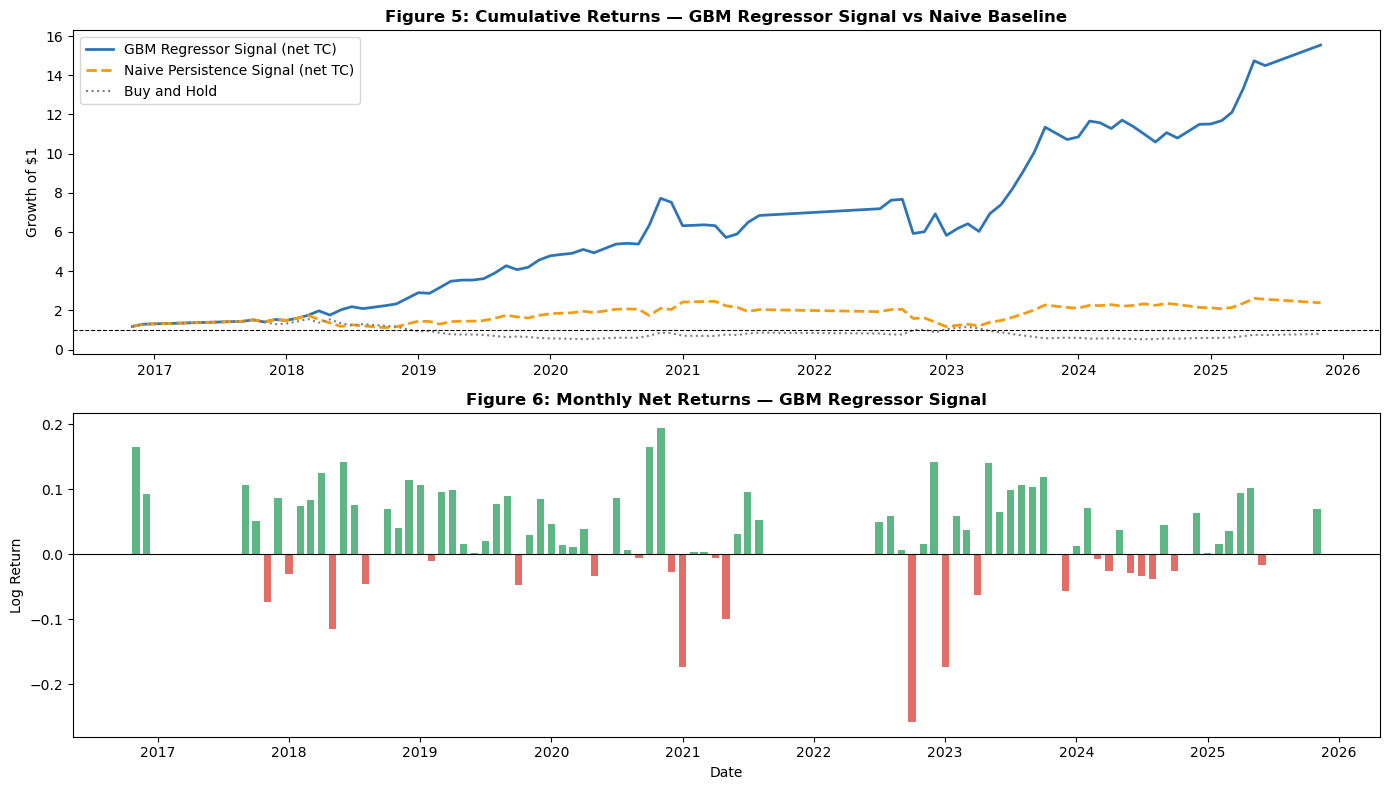


Saved trading strategy outputs.


In [37]:
# ---------------------------------------------------------
# Trading strategy simulation:
# Best-model signal vs naive persistence baseline
# ---------------------------------------------------------

strat = bt_best.copy().sort_values("date").reset_index(drop=True)

strat["actual_ret"] = strat["actual"]

# -----------------------------
# Best-model signal
# -----------------------------

is_clf_pred = set(strat["predicted"].unique()).issubset({0, 1})

if is_clf_pred:
    strat["model_signal"] = np.where(strat["predicted"] == 1, 1, -1)
else:
    strat["model_signal"] = np.where(
        strat["predicted"] > 0,
        1,
        np.where(strat["predicted"] < 0, -1, 0)
    )

# -----------------------------
# Naive baseline signal
# Predict next return using previous actual return
# -----------------------------

# Compute persistence from df_model before slicing the OOS window.
# This preserves the first valid OOS prediction, which uses the final
# in-sample target value as the previous observation.
naive_bt_for_strategy = create_naive_persistence_baseline(df_model)

strat = strat.merge(
    naive_bt_for_strategy[["date", "predicted"]].rename(
        columns={"predicted": "naive_predicted"}
    ),
    on="date",
    how="left"
)

if strat["naive_predicted"].isna().any():
    missing_dates = strat.loc[strat["naive_predicted"].isna(), "date"].tolist()
    raise ValueError(
        "Naive persistence predictions are missing for some strategy dates: "
        f"{missing_dates[:5]}"
    )

strat["naive_signal"] = np.where(
    strat["naive_predicted"] > 0,
    1,
    np.where(strat["naive_predicted"] < 0, -1, 0)
)

print(f"Trading strategy OOS rows: {len(strat)}")
print(f"Naive persistence OOS predictions: {len(naive_bt_for_strategy)}")
assert len(strat) == len(bt_best)
assert len(naive_bt_for_strategy) == len(df_model) - TRAIN_SIZE

# -----------------------------
# Trading cost and returns
# -----------------------------

tc_rate = 0.002

strat["model_trade"] = (
    strat["model_signal"].diff().abs()
    .fillna(strat["model_signal"].abs())
)

strat["naive_trade"] = (
    strat["naive_signal"].diff().abs()
    .fillna(strat["naive_signal"].abs())
)

strat["model_tc"] = strat["model_trade"] * tc_rate
strat["naive_tc"] = strat["naive_trade"] * tc_rate

strat["model_gross_ret"] = strat["model_signal"] * strat["actual_ret"]
strat["naive_gross_ret"] = strat["naive_signal"] * strat["actual_ret"]

strat["model_net_ret"] = strat["model_gross_ret"] - strat["model_tc"]
strat["naive_net_ret"] = strat["naive_gross_ret"] - strat["naive_tc"]

strat["bah_ret"] = strat["actual_ret"]

strat["model_eq"] = np.exp(strat["model_net_ret"].cumsum())
strat["naive_eq"] = np.exp(strat["naive_net_ret"].cumsum())
strat["bah_eq"] = np.exp(strat["bah_ret"].cumsum())


def ann_ret(r, n=12):
    """Calculate annualized return from periodic log returns."""
    return np.exp(r.mean() * n) - 1


def ann_vol(r, n=12):
    """Calculate annualized volatility."""
    return r.std() * np.sqrt(n)


def sharpe(r, n=12):
    """Calculate Sharpe ratio."""
    vol = ann_vol(r, n)
    return ann_ret(r, n) / vol if vol > 0 else np.nan


def mdd(eq):
    """Calculate maximum drawdown."""
    return ((eq / eq.cummax()) - 1).min()


perf = pd.DataFrame([
    {
        "Strategy": f"{best_name} Signal (net 0.2% TC)",
        "Ann. Return": ann_ret(strat["model_net_ret"]),
        "Ann. Vol": ann_vol(strat["model_net_ret"]),
        "Sharpe": sharpe(strat["model_net_ret"]),
        "Max DD": mdd(strat["model_eq"]),
        "Trades": (strat["model_trade"] > 0).sum(),
    },
    {
        "Strategy": "Naive Persistence Signal (net 0.2% TC)",
        "Ann. Return": ann_ret(strat["naive_net_ret"]),
        "Ann. Vol": ann_vol(strat["naive_net_ret"]),
        "Sharpe": sharpe(strat["naive_net_ret"]),
        "Max DD": mdd(strat["naive_eq"]),
        "Trades": (strat["naive_trade"] > 0).sum(),
    },
    {
        "Strategy": "Buy and Hold",
        "Ann. Return": ann_ret(strat["bah_ret"]),
        "Ann. Vol": ann_vol(strat["bah_ret"]),
        "Sharpe": sharpe(strat["bah_ret"]),
        "Max DD": mdd(strat["bah_eq"]),
        "Trades": 1,
    },
])

perf_display = perf.copy()

perf_display["Ann. Return"] = perf_display["Ann. Return"].map("{:.2%}".format)
perf_display["Ann. Vol"] = perf_display["Ann. Vol"].map("{:.2%}".format)
perf_display["Sharpe"] = perf_display["Sharpe"].map("{:.3f}".format)
perf_display["Max DD"] = perf_display["Max DD"].map("{:.2%}".format)

print(perf_display.to_string(index=False))

# -----------------------------
# Graph
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(
    strat["date"],
    strat["model_eq"],
    label=f"{best_name} Signal (net TC)",
    color="#2E75B6",
    lw=2
)

axes[0].plot(
    strat["date"],
    strat["naive_eq"],
    label="Naive Persistence Signal (net TC)",
    color="#F39C12",
    lw=2,
    linestyle="--"
)

axes[0].plot(
    strat["date"],
    strat["bah_eq"],
    label="Buy and Hold",
    color="gray",
    lw=1.5,
    linestyle=":"
)

axes[0].axhline(
    1,
    color="black",
    lw=0.8,
    linestyle="--"
)

axes[0].set_title(
    f"Figure 5: Cumulative Returns — {best_name} Signal vs Naive Baseline",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel("Growth of $1")
axes[0].legend()

cols = [
    "#1a9850" if r > 0 else "#d73027"
    for r in strat["model_net_ret"]
]

axes[1].bar(
    strat["date"],
    strat["model_net_ret"],
    color=cols,
    alpha=0.7,
    width=20
)

axes[1].axhline(
    0,
    color="black",
    lw=0.8
)

axes[1].set_title(
    f"Figure 6: Monthly Net Returns — {best_name} Signal",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("outputs/figure5_trading_strategy.png", dpi=150)
plt.show()

strat.to_csv("outputs/trading_strategy.csv", index=False)
perf.to_csv("outputs/trading_performance.csv", index=False)

print("\nSaved trading strategy outputs.")


---

## 8. Discussion

### 8.1 Primary Finding

The strongest stored result is the **Gradient Boosting Regressor without explicit SCFM**, which achieves **72.29% directional accuracy** across **83 out-of-sample monthly predictions**. The majority-class baseline is **54.96%**, so the best model improves on the baseline by **+17.33 percentage points**. The second-best model is **XGBoost without explicit SCFM** at **69.88% directional accuracy**.

The important correction is that the best-performing model is **GBM**, not a GBM/XGBoost tie. XGBoost performs well, but it is lower than GBM in the stored rolling-window results.

### 8.2 SCFM Findings

The explicit SCFM feature has a model-dependent effect, measured as:

\[
\Delta_{SCFM} = DA_{with\ SCFM} - DA_{without\ SCFM}
\]

The stored results show:

| Model | With SCFM | Without SCFM | SCFM impact |
|---|---:|---:|---:|
| Linear Regression | 61.45% | 59.04% | +2.41pp |
| Ridge Regression | 57.83% | 61.45% | −3.61pp |
| Lasso Regression | 65.06% | 66.27% | −1.20pp |
| KNN Regressor | 66.27% | 67.47% | −1.20pp |
| SVM Regressor | 56.63% | 57.83% | −1.20pp |
| Decision Tree Regressor | 54.22% | 68.67% | −14.46pp |
| Random Forest Regressor | 65.06% | 67.47% | −2.41pp |
| GBM Regressor | 66.27% | 72.29% | −6.02pp |
| XGBoost Regressor | 66.27% | 69.88% | −3.61pp |

The correct interpretation is narrower than the earlier draft: **explicit SCFM does not generally improve performance**. It helps only the basic linear model in the stored run. For the tree-based models, explicit SCFM is redundant or harmful, probably because the models can learn nonlinear interactions among copra prices, CNO prices, exchange rates, and other lagged inputs directly.

### 8.3 Weekly CPO Lags

Weekly CPO futures lags remain an important economic feature group because CNO and CPO are related vegetable-oil markets. The feature-importance section below should be used as the authoritative source for ranking individual predictors after the notebook is rerun end-to-end.

### 8.4 ENSO Signal

ONI lags are included to capture delayed ENSO-related production stress. Their role should be interpreted as incremental and secondary unless the feature-importance and ablation results show otherwise.

### 8.5 Limitations

- **Small sample:** The final model dataset has 131 monthly observations, and the rolling-window backtest produces only 83 out-of-sample forecasts.
- **Direction, not price level:** The target is next-month price direction, not the exact future CNO price.
- **Feature-engineering sensitivity:** SCFM depends on the assumed oil extraction rate, κ = 0.63. Actual copra oil content varies by region, processing quality, and season.
- **Potential feature redundancy:** Explicit SCFM overlaps mechanically with CNO, copra, and FX inputs. This can hurt flexible nonlinear models.
- **No trading-cost realism beyond the simple simulation:** The strategy section includes a 0.2% transaction cost but does not model liquidity, slippage, bid-ask spreads, contract constraints, or execution timing.
- **Stored notebook execution was previously interrupted:** The chart cell referenced `results["gbm"]`, but the actual model key is `"gbm_reg"`. That bug has been corrected so downstream statistical and trading sections can be rerun consistently.


---

## 9. Conclusion

This study finds that Philippine CNO export price direction is predictable above a simple majority-class benchmark using lagged world price signals, domestic supply-chain variables, exchange-rate features, production information, and ENSO climate indicators.

The three corrected conclusions are:

1. **The best stored model is GBM without explicit SCFM.** The Gradient Boosting Regressor achieves **72.29% directional accuracy** over **83 rolling-window out-of-sample predictions**, compared with the **54.96% majority-class baseline**. This is a **+17.33pp improvement**. XGBoost without SCFM is second at **69.88%**.

2. **Explicit SCFM is not universally beneficial.** In the stored results, explicit SCFM improves only Linear Regression (**+2.41pp**) and reduces performance for the remaining models. The largest losses occur in Decision Tree (**−14.46pp**), GBM (**−6.02pp**), and XGBoost (**−3.61pp**). The likely explanation is that flexible models can infer margin-like interactions from raw CNO, copra, and FX features without needing the explicit SCFM transformation.

3. **The result is stronger as a directional forecasting result than as a price-level forecasting result.** The model predicts whether next-month CNO log returns are positive or negative. It should not be presented as accurately forecasting the exact next-month CNO price unless a separate price-level error analysis supports that claim.

**Practical implications:** A monthly directional signal may help exporters, processors, and policymakers monitor the probability of near-term price increases or decreases. It is most defensible as a decision-support signal, not as a standalone trading or procurement rule.

**Future work** should extend the historical dataset, test alternative oil-extraction-rate assumptions for SCFM, add port and freight bottleneck variables if reliable data become available, compare unrestricted weekly lags against formal MIDAS specifications, and validate the framework on other Philippine agricultural export commodities.

---

## References

- Kumar Metal Industries. (2025). Copra or Coconut Oil Global Commercial Aspects. Retrieved from kumarmetal.com.
- Philippine Statistics Authority. (2024). OpenSTAT Agricultural Price Statistics. openstat.psa.gov.ph.
- World Bank. (2024). Commodity Markets Outlook: Pink Sheet Data. worldbank.org/en/research/commodity-markets.
- NOAA Climate Prediction Center. (2024). Oceanic Niño Index. cpc.ncep.noaa.gov.
- Global Info Research. (n.d.). *Coconut oil market report*. https://www.globalinforesearch.com/reports/2404844/coconut-oil
- Brownlee, J. (2020). Introduction to Time Series Forecasting with Python: How to Prepare Data and Develop Models to Predict the Future (v1.9). Machine Learning Mastery.


---
## 10. Save All Outputs


In [ ]:
for m,bt in results.items():
    bt.to_csv(f"outputs/backtest_with_scfm_{m}.csv",index=False)
for m,bt in results_ns.items():
    bt.to_csv(f"outputs/backtest_no_scfm_{m}.csv",index=False)

df_model.to_csv("outputs/df_model_final.csv",index=False)
comp_df.to_csv("outputs/model_comparison.csv",index=False)

if "results_pca" in globals():
    for m, bt in results_pca.items():
        bt.to_csv(f"outputs/backtest_pca_with_scfm_{m}.csv", index=False)
if "results_svd" in globals():
    for m, bt in results_svd.items():
        bt.to_csv(f"outputs/backtest_svd_with_scfm_{m}.csv", index=False)
if "results_pca_ns" in globals():
    for m, bt in results_pca_ns.items():
        bt.to_csv(f"outputs/backtest_pca_no_scfm_{m}.csv", index=False)
if "results_svd_ns" in globals():
    for m, bt in results_svd_ns.items():
        bt.to_csv(f"outputs/backtest_svd_no_scfm_{m}.csv", index=False)

if "dim_comp_df" in globals():
    dim_comp_df.to_csv("outputs/dimensionality_comparison_with_scfm.csv", index=False)
if "dim_comp_df_ns" in globals():
    dim_comp_df_ns.to_csv("outputs/dimensionality_comparison_no_scfm.csv", index=False)


print("All outputs saved to outputs/ folder.")
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Study period:        {df_model['date'].min().date()} to {df_model['date'].max().date()}")
print(f"Observations:        {len(df_model)} months")
print(f"Out-of-sample preds: {len(bt_best)}")
print(f"Majority baseline:   {baseline:.2%}")
print(f"Best model:          {best_name}")
print(f"Best DA (no SCFM):   {best_da:.2%}")
print(f"Improvement:         +{best_da-baseline:.2%}")
best_obs,_,best_cl,best_ch,best_p = block_bootstrap_da(
    bt_best["correct_direction"],baseline_da=baseline,block_size=6)
print(f"Bootstrap p-value:   {best_p:.4f}")
print(f"Bootstrap 95% CI:    [{best_cl:.2%}, {best_ch:.2%}]")

if "classification_comp_df" in globals():
    classification_comp_df.to_csv("outputs/classification_model_comparison.csv", index=False)
if "classification_results" in globals():
    for m, bt in classification_results.items():
        bt.to_csv(f"outputs/classification_backtest_with_scfm_{m}.csv", index=False)
if "classification_results_ns" in globals():
    for m, bt in classification_results_ns.items():
        bt.to_csv(f"outputs/classification_backtest_no_scfm_{m}.csv", index=False)

